# Proportion Metaphors CDS

In [ ]:
# --- Process Manchester Corpus: CDS Window 3 ---

from pathlib import Path
import re
import statistics

import pandas as pd


# This must be a directory, not the ZIP file itself.
FOLDER_CDS_3 = "data/manchester_context_3.zip"

SUBJECTS = [
    "Anne", "Aran", "Becky", "Carl", "Dominic", "Eleanor", "Fraser",
    "Gail", "Joel", "John", "Liz", "Nicole", "Ruth", "Warren"
]

SUBJECTS_SET = set(SUBJECTS)


def load_annotation(file_path):
    """Load annotated words from a MelBERT output file."""
    all_words = []

    with open(file_path, encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = re.split(r"\t+", line)

            if len(parts) <= 1:
                continue

            words = parts[1].rstrip()

            tokens = re.split(
                r"[\d\s.;,\n\t\r\[\]/\\!()?’‘_•—-]+",
                words
            )

            all_words.extend(
                token
                for token in tokens
                if any(char.isalpha() for char in token)
            )

    return all_words


def calculate_metaphor_metrics(words):
    """Calculate token- and type-based metaphor percentages."""
    metaphor_tokens = [
        word[1:].lower()
        for word in words
        if word.startswith("#")
    ]

    all_words = [
        word[1:].lower() if word.startswith("#") else word.lower()
        for word in words
    ]

    token_count = len(all_words)
    unique_words = set(all_words)
    unique_metaphors = set(metaphor_tokens)

    prop_met_tokens = (
        len(metaphor_tokens) / token_count * 100
        if token_count > 0
        else 0
    )

    prop_met_types = (
        len(unique_metaphors) / len(unique_words) * 100
        if unique_words
        else 0
    )

    return {
        "prop_met_tokens": prop_met_tokens,
        "prop_met_types": prop_met_types,
        "token_count": token_count,
        "token_metaphors": len(metaphor_tokens),
        "type_count": len(unique_words),
        "type_metaphors": len(unique_metaphors)
    }


def extract_subject(filename):
    """Extract the child's name from the filename."""
    return next(
        (
            subject
            for subject in SUBJECTS_SET
            if filename.startswith(subject)
        ),
        "Unknown"
    )


def extract_age_months(filename):
    """Extract age in YYMMDD format and convert it to months."""
    age_match = re.search(r"(\d{6})", filename)

    if not age_match:
        return None

    age_str = age_match.group(1)

    years = int(age_str[0:2])
    months = int(age_str[2:4])
    days = int(age_str[4:6])

    return years * 12 + months + days / 30


def process_cds_corpus(folder_path):
    """Process all CDS files and return metadata and metaphor metrics."""
    folder_path = Path(folder_path)

    if not folder_path.exists():
        raise FileNotFoundError(
            f"The folder does not exist:\n{folder_path}\n\n"
            "Check the folder name and location."
        )

    if not folder_path.is_dir():
        raise NotADirectoryError(
            f"This path is not an extracted folder:\n{folder_path}"
        )

    rows = []

    # rglob processes files in nested folders as well.
    candidate_files = sorted(
        file_path
        for file_path in folder_path.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in {".txt", ".csv"}
    )

    for file_path in candidate_files:
        words = load_annotation(file_path)

        if not words:
            continue

        metrics = calculate_metaphor_metrics(words)

        # Retaining the relative path allows the file to be located again later.
        relative_filename = str(file_path.relative_to(folder_path))

        rows.append({
            "filename": relative_filename,
            "name": extract_subject(file_path.name),
            "age": extract_age_months(file_path.name),
            **metrics
        })

    return pd.DataFrame(rows)


# --- Run processing ---

df_cds = process_cds_corpus(FOLDER_CDS_3)

prop_met_types_CDS = df_cds["prop_met_types"].tolist()
prop_met_tokens_CDS = df_cds["prop_met_tokens"].tolist()


# --- Display results ---

print(
    f"Processed {len(df_cds)} files "
    "for CDS / Manchester Window 3."
)

if not df_cds.empty:
    print(
        "Mean per-file proportion of metaphor types: "
        f"{statistics.mean(prop_met_types_CDS):.4f}%"
    )
    print(
        "Mean per-file proportion of metaphor tokens: "
        f"{statistics.mean(prop_met_tokens_CDS):.4f}%"
    )
else:
    print("No data processed for CDS / Manchester Window 3.")

print(df_cds.head())

Processed 617 files for CDS / Manchester Window 3.
Mean per-file proportion of metaphor types: 9.7884%
Mean per-file proportion of metaphor tokens: 5.5465%
                                            filename  name        age  \
0  manchester_context_3.zip (Unzipped Files)\Anne...  Anne  22.233333   
1  manchester_context_3.zip (Unzipped Files)\Anne...  Anne  22.700000   
2  manchester_context_3.zip (Unzipped Files)\Anne...  Anne  23.133333   
3  manchester_context_3.zip (Unzipped Files)\Anne...  Anne  23.200000   
4  manchester_context_3.zip (Unzipped Files)\Anne...  Anne  23.600000   

   prop_met_tokens  prop_met_types  token_count  token_metaphors  type_count  \
0         5.315917        9.297521         3292              175         484   
1         4.060067        8.092486         3596              146         519   
2         6.453348        8.905380         3719              240         539   
3         4.893101        9.243697         4537              222         595   
4    

In [ ]:
# --- Process Manchester Corpus: CDS Window 100 ---

FOLDER_CDS_100 = "data/manchester_context_100.zip"

# Process corpus using the same helper function as Window 3
df_cds_100 = process_cds_corpus(FOLDER_CDS_100)

# Extract metrics, consistently with Window 3 and Spoken
prop_met_types_CDS_100 = df_cds_100["prop_met_types"].tolist()
prop_met_tokens_CDS_100 = df_cds_100["prop_met_tokens"].tolist()

# --- Display results ---

print(
    f"Processed {len(df_cds_100)} files "
    "for CDS / Manchester Window 100."
)

if not df_cds_100.empty:
    print(
        "Mean per-file proportion of metaphor types: "
        f"{statistics.mean(prop_met_types_CDS_100):.4f}%"
    )
    print(
        "Mean per-file proportion of metaphor tokens: "
        f"{statistics.mean(prop_met_tokens_CDS_100):.4f}%"
    )
else:
    print("No data processed for CDS / Manchester Window 100.")

print(df_cds_100.head())

Processed 617 files for CDS / Manchester Window 100.
Mean Proportion Types: 10.4626%
Mean Proportion Tokens: 5.7676%
                              filename  name        age  prop_met_tokens  \
0  Anne011007_annotated_by_melbert.txt  Anne  22.233333         5.376671   
1  Anne011021_annotated_by_melbert.txt  Anne  22.700000         4.310345   
2  Anne011104_annotated_by_melbert.txt  Anne  23.133333         6.883571   
3  Anne011106_annotated_by_melbert.txt  Anne  23.200000         5.400044   
4  Anne011118_annotated_by_melbert.txt  Anne  23.600000         3.664049   

   prop_met_types  token_metaphors  type_metaphors  
0       10.330579              177              50  
1        9.055877              155              47  
2       10.760668              256              58  
3       10.756303              245              64  
4        7.993197              154              47  


In [74]:
# --- Compare CDS Window 3 vs Window 100: Types only ---
import scipy.stats as stats

# Keep only the columns needed for comparison
df_cds_w3 = df_cds[[
    "filename",
    "prop_met_types"
]].rename(columns={
    "prop_met_types": "prop_met_types_w3"
})

df_cds_w100 = df_cds_100[[
    "filename",
    "prop_met_types"
]].rename(columns={
    "prop_met_types": "prop_met_types_w100"
})

# Merge by filename to guarantee correct file alignment
df_cds_window_comparison = pd.merge(
    df_cds_w3,
    df_cds_w100,
    on="filename",
    how="inner"
)

print(f"CDS Window 3 files: {len(df_cds_w3)}")
print(f"CDS Window 100 files: {len(df_cds_w100)}")
print(f"Matched files used for correlation: {len(df_cds_window_comparison)}")

# Pearson correlation: metaphorical types
pearson_types_cds, p_types_cds = stats.pearsonr(
    df_cds_window_comparison["prop_met_types_w3"],
    df_cds_window_comparison["prop_met_types_w100"]
)

print("\n--- Pearson Correlation: CDS Window 3 vs Window 100 ---")
print(f"Types: r = {pearson_types_cds:.4f}, p = {p_types_cds:.4e}")

CDS Window 3 files: 617
CDS Window 100 files: 617
Matched files used for correlation: 617

--- Pearson Correlation: CDS Window 3 vs Window 100 ---
Types: r = 0.8475, p = 2.4063e-171


In [75]:
# --- Common Metaphor Types: 20 Most Frequent Metaphors in CDS ---
from collections import Counter
import pandas as pd
import os

all_metaphors_CDS = []

for filename in sorted(os.listdir(FOLDER_CDS_3)):
    if not filename.endswith((".txt", ".csv")):
        continue

    file_path = os.path.join(FOLDER_CDS_3, filename)

    if not os.path.isfile(file_path):
        continue

    words = load_annotation(file_path)

    metaphor_tokens = [
        word[1:].lower()
        for word in words
        if word.startswith("#")
    ]

    all_metaphors_CDS.extend(metaphor_tokens)

if all_metaphors_CDS:
    counter_cds = Counter(all_metaphors_CDS)
    types_20_cds = counter_cds.most_common(20)

    total_occurrences = len(all_metaphors_CDS)
    total_top_20 = sum(count for _, count in types_20_cds)
    coverage_percentage = (total_top_20 / total_occurrences) * 100

    df_top20_cds = pd.DataFrame(
        types_20_cds,
        columns=["metaphor_type", "count"]
    )

    print(f"Total metaphor tokens in CDS: {total_occurrences}")
    print(f"Total unique metaphor types in CDS: {len(counter_cds)}")
    print(f"Total occurrences of top 20: {total_top_20}")
    print(f"Coverage of top 20: {coverage_percentage:.2f}% of CDS metaphor tokens")

    print("\nTop 20 metaphor types in CDS:")
    display(df_top20_cds)

else:
    print("No metaphor tokens found in the CDS corpus.")

Total metaphor tokens in CDS: 150650
Total unique metaphor types in CDS: 2534
Total occurrences of top 20: 106930
Coverage of top 20: 70.98% of CDS metaphor tokens

Top 20 metaphor types in CDS:


,metaphor_type,count
0,that,23113
1,that's,18378
2,on,12468
3,this,7997
4,go,7409
5,come,5454
6,to,3835
7,there,3330
8,about,3190
9,those,2801


# Proportion Metaphors Spoken

In [ ]:
# --- Process Spoken Corpus: ADS / Spoken Window 3 ---

from pathlib import Path
import statistics

import pandas as pd


# Original folder location retained
FOLDER_SPOKEN_3 = "data/spoken_context_3.zip"


def process_spoken_corpus(folder_path):
    """
    Process all Spoken/ADS files and return a DataFrame containing
    filenames and metaphor metrics.
    """
    folder_path = Path(folder_path)

    if not folder_path.exists():
        raise FileNotFoundError(
            f"The folder does not exist:\n{folder_path}"
        )

    if not folder_path.is_dir():
        raise NotADirectoryError(
            f"This path is not a directory:\n{folder_path}"
        )

    rows = []

    candidate_files = sorted(
        file_path
        for file_path in folder_path.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in {".txt", ".csv"}
    )

    for file_path in candidate_files:
        words = load_annotation(file_path)

        if not words:
            continue

        metrics = calculate_metaphor_metrics(words)
        relative_filename = str(file_path.relative_to(folder_path))

        rows.append({
            "filename": relative_filename,
            **metrics
        })

    return pd.DataFrame(rows)


# --- Run processing ---

df_spok = process_spoken_corpus(FOLDER_SPOKEN_3)


# --- Extract and display results ---

print(
    f"Processed {len(df_spok)} files "
    "for ADS / Spoken Window 3."
)

if not df_spok.empty:
    prop_met_types_Spok = df_spok["prop_met_types"].tolist()
    prop_met_tokens_Spok = df_spok["prop_met_tokens"].tolist()

    print(
        "Mean per-file proportion of metaphor types: "
        f"{statistics.mean(prop_met_types_Spok):.4f}%"
    )
    print(
        "Mean per-file proportion of metaphor tokens: "
        f"{statistics.mean(prop_met_tokens_Spok):.4f}%"
    )
else:
    prop_met_types_Spok = []
    prop_met_tokens_Spok = []

    print("No data processed for ADS / Spoken Window 3.")

print(df_spok.head())

Processed 255 files for ADS / Spoken Window 3.
Mean per-file proportion of metaphor types: 14.5871%
Mean per-file proportion of metaphor tokens: 8.9831%
                                            filename  prop_met_tokens  \
0  spoken_context_3.zip (Unzipped Files)\D8Y_anno...         7.712964   
1  spoken_context_3.zip (Unzipped Files)\D92_anno...        10.414201   
2  spoken_context_3.zip (Unzipped Files)\D96_anno...         9.789343   
3  spoken_context_3.zip (Unzipped Files)\F73_anno...         7.142857   
4  spoken_context_3.zip (Unzipped Files)\F75_anno...         8.557047   

   prop_met_types  token_count  token_metaphors  type_count  type_metaphors  
0       10.789324         6703              517        1761             190  
1       14.022140          845               88         271              38  
2       14.432990          807               79         291              42  
3       12.571429          392               28         175              22  
4       11.715481 

In [ ]:
# --- Process Spoken Corpus: ADS / Spoken Window 100 ---

FOLDER_SPOKEN_100 = "data/spoken_context_100.zip"

# Process corpus using the same helper function as Spoken Window 3
df_spok_100 = process_spoken_corpus(FOLDER_SPOKEN_100)

# Extract metrics
prop_met_types_Spok_100 = df_spok_100["prop_met_types"].tolist()
prop_met_tokens_Spok_100 = df_spok_100["prop_met_tokens"].tolist()

# --- Display results ---
print(f"Processed {len(df_spok_100)} files for ADS / Spoken Window 100.")

if not df_spok_100.empty:
    print(f"Mean Proportion Types: {statistics.mean(prop_met_types_Spok_100):.4f}%")
    print(f"Mean Proportion Tokens: {statistics.mean(prop_met_tokens_Spok_100):.4f}%")
else:
    print("No data processed for ADS / Spoken Window 100.")

print(df_spok_100.head())

Processed 253 files for ADS / Spoken Window 100.
Mean Proportion Types: 19.1770%
Mean Proportion Tokens: 11.8567%
                       filename  prop_met_tokens  prop_met_types  \
0  D8Y_annotated_by_melbert.txt         9.622557       13.117547   
1  D92_annotated_by_melbert.txt        15.739645       22.509225   
2  D96_annotated_by_melbert.txt        13.011152       16.151203   
3  F73_annotated_by_melbert.txt         8.673469       13.714286   
4  F75_annotated_by_melbert.txt        12.248322       17.154812   

   token_metaphors  type_metaphors  
0              645             231  
1              133              61  
2              105              47  
3               34              24  
4               73              41  


In [78]:
# --- Process Filtered Corpora for Fair Comparison: Spoken Window 3 vs Window 100 ---
import pandas as pd
from scipy import stats

# Keep only the columns needed for comparison
df_spok_w3 = df_spok[[
    "filename",
    "prop_met_types",
    "prop_met_tokens"
]].rename(columns={
    "prop_met_types": "prop_met_types_w3",
    "prop_met_tokens": "prop_met_tokens_w3"
})

df_spok_w100 = df_spok_100[[
    "filename",
    "prop_met_types",
    "prop_met_tokens"
]].rename(columns={
    "prop_met_types": "prop_met_types_w100",
    "prop_met_tokens": "prop_met_tokens_w100"
})

# Merge by filename to guarantee correct file alignment
df_spok_window_comparison = pd.merge(
    df_spok_w3,
    df_spok_w100,
    on="filename",
    how="inner"
)

print(f"Spoken Window 3 files: {len(df_spok_w3)}")
print(f"Spoken Window 100 files: {len(df_spok_w100)}")
print(f"Matched files used for correlation: {len(df_spok_window_comparison)}")

# Pearson correlation: metaphorical types
pearson_types_spok, p_types_spok = stats.pearsonr(
    df_spok_window_comparison["prop_met_types_w3"],
    df_spok_window_comparison["prop_met_types_w100"]
)

# Pearson correlation: metaphorical tokens
pearson_tokens_spok, p_tokens_spok = stats.pearsonr(
    df_spok_window_comparison["prop_met_tokens_w3"],
    df_spok_window_comparison["prop_met_tokens_w100"]
)

print("\n--- Pearson Correlations: Spoken Window 3 vs Window 100 ---")
print(f"Types:  r = {pearson_types_spok:.4f}, p = {p_types_spok:.4e}")
print(f"Tokens: r = {pearson_tokens_spok:.4f}, p = {p_tokens_spok:.4e}")

Spoken Window 3 files: 255
Spoken Window 100 files: 253
Matched files used for correlation: 253

--- Pearson Correlations: Spoken Window 3 vs Window 100 ---
Types:  r = 0.9503, p = 3.2465e-129
Tokens: r = 0.9553, p = 8.6355e-135


In [79]:
# --- Mean Proportions Using Only Matched Files: CDS and ADS/Spoken ---
import pandas as pd

def make_matched_window_dataframe(df_w3, df_w100):
    """
    Merge Window 3 and Window 100 data by filename,
    keeping both type- and token-based metaphor proportions.
    """
    df_w3_small = df_w3[[
        "filename",
        "prop_met_types",
        "prop_met_tokens"
    ]].rename(columns={
        "prop_met_types": "prop_met_types_w3",
        "prop_met_tokens": "prop_met_tokens_w3"
    })

    df_w100_small = df_w100[[
        "filename",
        "prop_met_types",
        "prop_met_tokens"
    ]].rename(columns={
        "prop_met_types": "prop_met_types_w100",
        "prop_met_tokens": "prop_met_tokens_w100"
    })

    return pd.merge(
        df_w3_small,
        df_w100_small,
        on="filename",
        how="inner"
    )


def summarize_matched_window_means(df_matched, corpus_label):
    """
    Compute mean metaphor proportions using only files matched
    across Window 3 and Window 100.
    """
    return pd.DataFrame({
        "Corpus": [corpus_label, corpus_label, corpus_label, corpus_label],
        "Window size": [100, 100, 3, 3],
        "Measure": ["Tokens", "Types", "Tokens", "Types"],
        "Mean proportion (%)": [
            df_matched["prop_met_tokens_w100"].mean(),
            df_matched["prop_met_types_w100"].mean(),
            df_matched["prop_met_tokens_w3"].mean(),
            df_matched["prop_met_types_w3"].mean()
        ],
        "N matched files": [len(df_matched)] * 4
    })


# Rebuild matched-file comparison dataframes
df_cds_window_comparison_full = make_matched_window_dataframe(
    df_cds,
    df_cds_100
)

df_spok_window_comparison_full = make_matched_window_dataframe(
    df_spok,
    df_spok_100
)

print(f"CDS matched files: {len(df_cds_window_comparison_full)}")
print(f"ADS/Spoken matched files: {len(df_spok_window_comparison_full)}")

# Compute means
cds_matched_means = summarize_matched_window_means(
    df_cds_window_comparison_full,
    "CDS"
)

spok_matched_means = summarize_matched_window_means(
    df_spok_window_comparison_full,
    "ADS"
)

matched_means_summary = pd.concat(
    [cds_matched_means, spok_matched_means],
    ignore_index=True
)

matched_means_summary["Mean proportion (%)"] = matched_means_summary[
    "Mean proportion (%)"
].round(3)

display(matched_means_summary)

CDS matched files: 617
ADS/Spoken matched files: 253


,Corpus,Window size,Measure,Mean proportion (%),N matched files
0,CDS,100,Tokens,5.768,617
1,CDS,100,Types,10.463,617
2,CDS,3,Tokens,5.546,617
3,CDS,3,Types,9.788,617
4,ADS,100,Tokens,11.857,253
5,ADS,100,Types,19.177,253
6,ADS,3,Tokens,9.014,253
7,ADS,3,Types,14.635,253


In [80]:
# --- Common Metaphor Types: 20 Most Frequent Metaphors in Matched Spoken Corpus ---
from collections import Counter
import pandas as pd
import os

# Use only files that are matched between Spoken Window 3 and Window 100
matched_spok_files = set(df_spok_window_comparison_full["filename"])

all_metaphors_Spok = []

for filename in sorted(matched_spok_files):
    file_path = os.path.join(FOLDER_SPOKEN_3, filename)

    if not os.path.isfile(file_path):
        continue

    words = load_annotation(file_path)

    metaphor_tokens = [
        word[1:].lower()
        for word in words
        if word.startswith("#")
    ]

    all_metaphors_Spok.extend(metaphor_tokens)

if all_metaphors_Spok:
    counter_spok = Counter(all_metaphors_Spok)
    types_20_spok = counter_spok.most_common(20)

    total_occurrences = len(all_metaphors_Spok)
    total_top_20 = sum(count for _, count in types_20_spok)
    coverage_percentage = (total_top_20 / total_occurrences) * 100

    df_top20_spok = pd.DataFrame(
        types_20_spok,
        columns=["metaphor_type", "count"]
    )

    print(f"Matched Spoken files analyzed: {len(matched_spok_files)}")
    print(f"Total metaphor tokens in matched Spoken corpus: {total_occurrences}")
    print(f"Total unique metaphor types in matched Spoken corpus: {len(counter_spok)}")
    print(f"Total occurrences of top 20: {total_top_20}")
    print(f"Coverage of top 20: {coverage_percentage:.2f}% of matched Spoken metaphor tokens")

    print("\nTop 20 metaphor types in matched Spoken corpus:")
    display(df_top20_spok)

else:
    print("No metaphor tokens found in the matched Spoken corpus.")

Matched Spoken files analyzed: 253
Total metaphor tokens in matched Spoken corpus: 261228
Total unique metaphor types in matched Spoken corpus: 5858
Total occurrences of top 20: 141375
Coverage of top 20: 54.12% of matched Spoken metaphor tokens

Top 20 metaphor types in matched Spoken corpus:


,metaphor_type,count
0,that,28088
1,on,14762
2,in,13780
3,this,12155
4,to,11933
5,that's,11484
6,about,9985
7,with,6413
8,at,3841
9,those,3239


# Graph: Proportions of Metaphors

In [ ]:
from matplotlib.font_manager import FontProperties
personal_path = 'provide yours'

# get normal font and store it in `Helvetica`
font_path = personal_path + 'helveticaneue.ttf'
Helvetica = FontProperties(fname=font_path)

In [ ]:
# --- Violin plot: Metaphorical tokens in CDS vs ADS, Window 3 ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Extract current Window 3 token-level metaphor proportions
prop_met_tokens_CDS = df_cds["prop_met_tokens"].dropna().tolist()
prop_met_tokens_ADS = df_spok["prop_met_tokens"].dropna().tolist()

# Combine into plotting dataframe
plot_data = {
    "CDS": prop_met_tokens_CDS,
    "ADS": prop_met_tokens_ADS
}

df_plot = pd.DataFrame({
    corpus: pd.Series(values)
    for corpus, values in plot_data.items()
})

data = [
    df_plot["CDS"].dropna(),
    df_plot["ADS"].dropna()
]

labels = [
    "Child-directed speech",
    "Adult-directed speech"
]

x = np.arange(1, len(data) + 1)
means = [np.mean(sample) for sample in data]

# Colors for the two registers
colors = ["#377eb8", "#ff7f00"]

plt.figure(figsize=(20, 17), dpi=600)

plots = plt.violinplot(
    data,
    showmeans=False,
    showextrema=False,
    showmedians=False
)

# Set violin colors
for pc, color in zip(plots["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor("black")
    pc.set_alpha(0.8)

# Add horizontal mean ticks and mean labels
for i, mean in enumerate(means, start=1):
    plt.hlines(
        y=mean,
        xmin=i - 0.25,
        xmax=i + 0.25,
        color="black",
        linewidth=3
    )

    plt.text(
        i + 0.28,
        mean,
        f"M = {mean:.2f}",
        fontsize=24,
        va="center",
        fontname="Helvetica"
    )

# Titles and labels
plt.title(
    "Percentage of Metaphorical Tokens across Spoken Registers",
    fontname="Helvetica",
    size=33,
    pad=20
)

plt.ylabel(
    "Percentage of metaphorical tokens",
    fontname="Helvetica",
    size=30
)

plt.xticks(
    x,
    labels,
    fontname="Helvetica",
    size=28
)

plt.yticks(
    fontname="Helvetica",
    size=24
)

plt.grid(True, axis="y", alpha=0.3)

plt.margins(0.2)
plt.subplots_adjust(bottom=0.15)

# Save figure
output_path = r"C:\Users\lvfeu\Desktop\Percentage_met_Tokens_W3_2.jpg"
plt.savefig(output_path, dpi=600, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_path}")
print(f"CDS mean: {means[0]:.4f}%")
print(f"ADS mean: {means[1]:.4f}%")

# Reliability Analysis

In [ ]:
# Reliabilities Ground Truth vs MelBERT SPOKEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

from sklearn import metrics
spoken_GT = "data\BNC_spoken_to_annotate_GT.txt"
spoken_melbert = "data\BNC_spoken_annotated_by_melbert.txt"
spoken_1 = "data\BNC_spoken_to_annotate.txt"
spoken_2 = "data\BNC_spoken_to_annotate_Kim.txt"
written_1 = "data\BNC_written_to_annotate.txt"
written_2 = "data\BNC_written_to_annotate_Kim.txt"
written_GT = "data\BNC_written_to_annotate_GT.txt"
written_melbert = "data\BNC_written_annotated_by_melbert.txt"
CDS_1 = "data\Manchester_to_annotate.txt"
CDS_2 = "data\Manchester_to_annotate_Kim.txt"
CDS_GT = "data\Manchester_to_annotate_GT.txt"
CDS_melbert = "data\Manchester_annotated_by_melbert.txt"

words_gt = load_annotation(spoken_GT)
words_test = load_annotation(spoken_melbert)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Annotator 1 vs Annotator 2 SPOKEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(spoken_1)
words_test = load_annotation(spoken_2)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Ground Truth vs MelBERT WRITTEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(written_GT)
words_test = load_annotation(written_melbert)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Annotator 1 vs Annotator 2 WRITTEN
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(written_1)
words_test = load_annotation(written_2)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Ground Truth vs MelBERT CDS
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(CDS_GT)
words_test = load_annotation(CDS_melbert)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


In [ ]:
# Reliabilities Annotator 1 vs Annotator 2 CDS
# Accuracy, Cohen's kappa, precision, recall and f-score.

words_gt = load_annotation(CDS_1)
words_test = load_annotation(CDS_2)

if len(words_gt) != len(words_test):
  raise Exception("mismatch in number of words:", len(words_gt), len(words_test))

num_positive = 0
num_negative = 0
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0
errors = []

target_labels = []
predicted_labels = []

for word_gt, word_test in zip(words_gt, words_test):

  if word_gt.startswith("#"):
    num_positive += 1
    target_labels.append("1")
    if word_test == word_gt:
      true_positive += 1
      predicted_labels.append("1")
    elif word_gt == "#" + word_test:
      false_negative += 1
      predicted_labels.append("0")
    else:
      num_positive -= 1
      target_labels.pop()
      errors.append((word_gt, word_test))
  else:
    num_negative += 1
    target_labels.append("0")
    if word_test == word_gt:
      true_negative += 1
      predicted_labels.append("0")
    elif word_test == "#" + word_gt:
      false_positive += 1
      predicted_labels.append("1")
    else:
      target_labels.pop()
      num_negative -= 1
      errors.append((word_gt, word_test))

print("errors: ", errors)

if len(words_gt) != num_negative + num_positive + len(errors):
  raise Exception(len(words_gt), num_negative, num_positive, len(errors))
if true_positive + false_negative != num_positive: 
  raise Exception(true_positive, false_negative, num_positive)
if true_negative + false_positive != num_negative:
  raise Exception(true_negative, false_positive, num_negative)

accuracy = (true_positive + true_negative) / (num_positive + num_negative)
cohen_kappa = metrics.cohen_kappa_score(target_labels, predicted_labels)
precision = true_positive / (true_positive + false_positive)
recall = true_positive / num_positive
f_score = 2 / (1/recall + 1/precision)

print(false_negative, false_positive, true_negative, true_positive)

print(num_positive, "metaphors out of", num_positive + num_negative, "words")
print("accuracy: ", accuracy)
print("precision: ", precision)
print("recall: ", recall)
print("f_score:", f_score)
print("cohen's kappa:", cohen_kappa)


## CONCRETENESS

In [1]:
# Dictionary transformations

word_dict = {"ain't": 'be', 'analyse': 'analyze', 'and/or': 'and', 'antagonise': 'antagonize', "asn't": 'as', 'aways': 'away', 'behaviour': 'behavior', 'behavioural': 'behavior', "can't": 'can', 'categorise': 'categorize', 'centralise': 'centralize', 'centre': 'center', 'characterise': 'characterize', 'cheque': 'check', 'colour': 'color', 'computerisation': 'computerization', 'counsellor': 'counselor', 'criticise': 'criticize', 'customise': 'customize', 'defence': 'defense', 'dialling': 'dialing', 'digitise': 'digitize', 'discus': 'discuss', 'discusss': 'discuss', 'discusssed': 'discuss', 'discusssion': 'discussion', 'empathise': 'empathize', 'emphasise': 'emphasize', 'encyclopaedia': 'encyclopedia', 'favour': 'favor', 'favourable': 'favorable', 'fibre': 'fiber', 'formalise': 'formalize', 'fulfil': 'fulfill', 'fulfilllment': 'fulfilment', 'generalisation': 'generalization', "hadn't": 'have', 'harmonisation': 'harmonization', 'homogenisation': 'homogenization', 'honour': 'honor', 'hospitalisation': 'hospitalization', 'individualise': 'individualized', 'industrialisation': 'industrialization', 'industrialise': 'industrialize', "isn't": 'be', 'kompass': 'compass', 'labour': 'labor', 'liberalisation': 'liberalization', 'maximise': 'maximize', 'memorise': 'memorize', 'metre': 'meter', 'minimise': 'minimize', 'neighbour': 'neighbor', 'neutralisation': 'neutralization', 'organisation': 'organization', 'organise': 'organize', 'organiser': 'organizer', 'organises': 'organize', 'personalise': 'personalize', 'personalised': 'personalized', 'philosophe': 'philosophy', 'practise': 'practice', 'programme': 'program', 'publicise': 'publicize', 'pulverise': 'pulverize', 'realise': 'realize', 'recognise': 'recognize', 'revolutionise': 'revolutionize', 'rumour': 'rumor', 'secularise': 'secularize', "shan't": 'shall', 'skilful': 'skillful', 'specialisation': 'specialization', 'specialise': 'specialize', 'standardise': 'standardize', 'suited': 'suitable', 'summarise': 'summarize', 'synchronise': 'synchronize', 'telly': 'TV', 'theatre': 'theater', 'unfavourable': 'unfavorable', 'utilise': 'utilize', "von't": 'be', "won't": 'be', "you're": 'you'}

newtuple = {'ablated': 'VERB', 'abolishing': 'VERB', 'abused': 'VERB', 'accelerating': 'VERB', 'accented': 'VERB', 'accepting': 'VERB', 'accessing': 'VERB', 'acclaimed': 'VERB', 'accumulated': 'VERB', 'accumulating': 'VERB', 'accusing': 'VERB', 'achieved': 'VERB', 'acknowledging': 'VERB', 'acknowleged': 'VERB', 'acompanied': 'VERB', 'activated': 'VERB', 'activating': 'VERB', 'adapted': 'VERB', 'adding': 'VERB', 'addressed': 'VERB', 'adjusting': 'VERB', 'administered': 'VERB', 'adopting': 'VERB', 'adored': 'VERB', 'adulterated': 'VERB', 'advantaged': 'VERB', 'adventuring': 'VERB', 'affiliated': 'VERB', 'affixed': 'VERB', 'ageing': 'VERB', 'aggrevated': 'VERB', 'agonised': 'VERB', 'aided': 'VERB', 'airlifting': 'VERB', 'aisling': 'VERB', 'alerted': 'VERB', 'alienated': 'VERB', 'allocated': 'VERB', 'allocating': 'VERB', 'allotted': 'VERB', 'allowed': 'VERB', 'allowing': 'VERB', 'altered': 'VERB', 'amalgamated': 'VERB', 'amassed': 'VERB', 'amended': 'VERB', 'amending': 'VERB', 'amounted': 'VERB', 'amounting': 'VERB', 'amplified': 'VERB', 'analysing': 'VERB', 'analyzed': 'VERB', 'angered': 'VERB', 'angrier': 'ADJ', 'annealing': 'VERB', 'annotated': 'VERB', 'announced': 'VERB', 'annualised': 'VERB', 'answering': 'VERB', 'anthropomorphized': 'VERB', 'anticipated': 'VERB', 'apologised': 'VERB', 'appealed': 'VERB', 'appeared': 'VERB', 'appearing': 'VERB', 'appeased': 'VERB', 'appened': 'VERB', 'appetising': 'VERB', 'applying': 'VERB', 'appointed': 'VERB', 'appreciated': 'VERB', 'apprised': 'VERB', 'approached': 'VERB', 'approved': 'VERB', 'archiving': 'VERB', 'arguing': 'VERB', 'arising': 'VERB', 'armoured': 'VERB', 'aroused': 'VERB', 'arranged': 'VERB', 'arranging': 'VERB', 'arrived': 'VERB', 'arriving': 'VERB', 'arrowing': 'VERB', 'arsed': 'VERB', 'ascertaining': 'VERB', 'ascribing': 'VERB', 'asked': 'VERB', 'asking': 'VERB', 'asphyxiating': 'VERB', 'aspirated': 'VERB', 'assayed': 'VERB', 'assembled': 'VERB', 'assembling': 'VERB', 'assessing': 'VERB', 'assessmented': 'VERB', 'assisted': 'VERB', 'ated': 'VERB', 'atomised': 'VERB', 'attacked': 'VERB', 'attacking': 'VERB', 'attempting': 'VERB', 'attended': 'VERB', 'attenuated': 'VERB', 'attested': 'VERB', 'attracted': 'VERB', 'attuned': 'VERB', 'audited': 'VERB', 'auditing': 'VERB', 'authorised': 'VERB', 'autoclaved': 'VERB', 'autopsied': 'VERB', 'avaunced': 'VERB', 'aveling': 'VERB', 'averaged': 'VERB', 'averaging': 'VERB', 'averting': 'VERB', 'avoided': 'VERB', 'awaited': 'VERB', 'awaiting': 'VERB', 'awarded': 'VERB', 'awarding': 'VERB', 'babysitting': 'VERB', 'backlighted': 'VERB', 'baiting': 'VERB', 'bandaging': 'VERB', 'banned': 'VERB', 'baptized': 'VERB', 'barging': 'VERB', 'baring': 'VERB', 'barked': 'VERB', 'barracking': 'VERB', 'barricading': 'VERB', 'bashed': 'VERB', 'bashing': 'VERB', 'battling': 'VERB', 'bawled': 'VERB', 'bawling': 'VERB', 'beaked': 'VERB', 'beatified': 'VERB', 'bedecked': 'VERB', 'bedraggled': 'VERB', 'bedroomed': 'VERB', 'beefing': 'VERB', 'beered': 'VERB', 'beeswaxed': 'VERB', 'befeathered': 'VERB', 'befriending': 'VERB', 'behaved': 'VERB', 'behaving': 'VERB', 'beheading': 'VERB', 'belching': 'VERB', 'beleaguered': 'VERB', 'believed': 'VERB', 'bellowing': 'VERB', 'belonged': 'VERB', 'bemused': 'VERB', 'benefiting': 'VERB', 'benighted': 'VERB', 'besotted': 'VERB', 'betrayed': 'VERB', 'betraying': 'VERB', 'bickering': 'VERB', 'bicolored': 'VERB', 'bicycling': 'VERB', 'biking': 'VERB', 'bitching': 'VERB', 'blacksided': 'VERB', 'blanched': 'VERB', 'blaring': 'VERB', 'blazered': 'VERB', 'blemished': 'VERB', 'blicking': 'VERB', 'blighter': 'ADJ', 'blitzed': 'VERB', 'blitzer': 'ADJ', 'blonded': 'VERB', 'bloodsoaked': 'VERB', 'blossoming': 'VERB', 'blurring': 'VERB', 'blusher': 'ADJ', 'bogged': 'VERB', 'bolder': 'ADJ', 'boldest': 'ADJ', 'bollocking': 'VERB', 'bolted': 'VERB', 'booring': 'VERB', 'boosting': 'VERB', 'bootstring': 'VERB', 'boozing': 'VERB', 'borrowed': 'VERB', 'bothered': 'VERB', 'bothering': 'VERB', 'botting': 'VERB', 'bouldering': 'VERB', 'boulting': 'VERB', 'bowering': 'VERB', 'bowled': 'VERB', 'boxed': 'VERB', 'braindamaged': 'VERB', 'braking': 'VERB', 'branding': 'VERB', 'brandishing': 'VERB', 'brasher': 'ADJ', 'breakfasting': 'VERB', 'brewed': 'VERB', 'bricked': 'VERB', 'brighter': 'ADJ', 'brightest': 'ADJ', 'brindled': 'VERB', 'brindling': 'VERB', 'bringing': 'VERB', 'broached': 'VERB', 'broadening': 'VERB', 'brokered': 'VERB', 'broking': 'VERB', 'brooking': 'VERB', 'brouzed': 'VERB', 'bruised': 'VERB', 'buckling': 'VERB', 'budgeting': 'VERB', 'buffered': 'VERB', 'buffeting': 'VERB', 'bulging': 'VERB', 'bulking': 'VERB', 'bumbling': 'VERB', 'bundled': 'VERB', 'bungled': 'VERB', 'bungling': 'VERB', 'burbling': 'VERB', 'bureaucratised': 'VERB', 'burgeoning': 'VERB', 'burnished': 'VERB', 'burrowing': 'VERB', 'bursting': 'VERB', 'busting': 'VERB', 'buttressed': 'VERB', 'buxted': 'VERB', 'buying': 'VERB', 'cackling': 'VERB', 'caking': 'VERB', 'called': 'VERB', 'calming': 'VERB', 'calved': 'VERB', 'calving': 'VERB', 'camouflaged': 'VERB', 'campaigning': 'VERB', 'campling': 'VERB', 'cancelling': 'VERB', 'caning': 'VERB', 'canopied': 'VERB', 'canvassing': 'VERB', 'captioning': 'VERB', 'captured': 'VERB', 'caricatured': 'VERB', 'carpeted': 'VERB', 'carved': 'VERB', 'cataloguing': 'VERB', 'caused': 'VERB', 'ceilinged': 'VERB', 'celebrating': 'VERB', 'censored': 'VERB', 'centring': 'VERB', 'chafed': 'VERB', 'chafing': 'VERB', 'challenging': 'VERB', 'changed': 'VERB', 'changing': 'VERB', 'chapelled': 'VERB', 'characterized': 'VERB', 'charged': 'VERB', 'charing': 'VERB', 'charmed': 'VERB', 'chastising': 'VERB', 'cheaper': 'ADJ', 'cheapest': 'ADJ', 'checking': 'VERB', 'checkred': 'VERB', 'cherished': 'VERB', 'chested': 'VERB', 'chesting': 'VERB', 'chewed': 'VERB', 'chewing': 'VERB', 'chiselled': 'VERB', 'chitted': 'VERB', 'chitting': 'VERB', 'chorussing': 'VERB', 'chucked': 'VERB', 'chucking': 'VERB', 'chuckled': 'VERB', 'chuffed': 'VERB', 'chugging': 'VERB', 'civilised': 'VERB', 'cladding': 'VERB', 'claimed': 'VERB', 'claiming': 'VERB', 'clamping': 'VERB', 'clarifying': 'VERB', 'clasped': 'VERB', 'clattering': 'VERB', 'clavering': 'VERB', 'cleanest': 'ADJ', 'cleared': 'VERB', 'clearest': 'ADJ', 'clenched': 'VERB', 'clenching': 'VERB', 'cleverer': 'ADJ', 'clicking': 'VERB', 'climaxed': 'VERB', 'clinched': 'VERB', 'closest': 'ADJ', 'closing': 'VERB', 'clothed': 'VERB', 'clothmaking': 'VERB', 'clumping': 'VERB', 'clutching': 'VERB', 'cluttered': 'VERB', 'coaling': 'VERB', 'coarser': 'ADJ', 'coarsing': 'VERB', 'cobbled': 'VERB', 'coddling': 'VERB', 'coded': 'VERB', 'codenamed': 'VERB', 'codified': 'VERB', 'codling': 'VERB', 'coldest': 'ADJ', 'collapsed': 'VERB', 'collapsing': 'VERB', 'collecting': 'VERB', 'combatting': 'VERB', 'commandeered': 'VERB', 'commenting': 'VERB', 'commissioned': 'VERB', 'commissioning': 'VERB', 'committed': 'VERB', 'commonest': 'ADJ', 'compared': 'VERB', 'comparing': 'VERB', 'competing': 'VERB', 'compiled': 'VERB', 'compiling': 'VERB', 'complaining': 'VERB', 'complicating': 'VERB', 'comprehending': 'VERB', 'comprising': 'VERB', 'compromised': 'VERB', 'computed': 'VERB', 'computerised': 'VERB', 'concatenated': 'VERB', 'concealing': 'VERB', 'conceding': 'VERB', 'conceived': 'VERB', 'concentrating': 'VERB', 'conceptualising': 'VERB', 'concreted': 'VERB', 'condoning': 'VERB', 'conducting': 'VERB', 'confided': 'VERB', 'confronted': 'VERB', 'confronting': 'VERB', 'congratulating': 'VERB', 'connecting': 'VERB', 'conniving': 'VERB', 'conserved': 'VERB', 'consisted': 'VERB', 'consisting': 'VERB', 'constructed': 'VERB', 'construed': 'VERB', 'consummated': 'VERB', 'contacted': 'VERB', 'containing': 'VERB', 'contaminated': 'VERB', 'contemplated': 'VERB', 'continuing': 'VERB', 'contolled': 'VERB', 'contracting': 'VERB', 'contrasting': 'VERB', 'contributing': 'VERB', 'contrived': 'VERB', 'controlled': 'VERB', 'controlling': 'VERB', 'convalescing': 'VERB', 'convened': 'VERB', 'conventionalized': 'VERB', 'conveyancing': 'VERB', 'conveyed': 'VERB', 'convicted': 'VERB', 'cooled': 'VERB', 'coolest': 'ADJ', 'cooped': 'VERB', 'coordinated': 'VERB', 'coordinating': 'VERB', 'coppering': 'VERB', 'copulating': 'VERB', 'copying': 'VERB', 'cored': 'VERB', 'costed': 'VERB', 'costliest': 'ADJ', 'coughed': 'VERB', 'coughing': 'VERB', 'counselling': 'VERB', 'counted': 'VERB', 'counterfeiting': 'VERB', 'couping': 'VERB', 'coving': 'VERB', 'cowled': 'VERB', 'coxing': 'VERB', 'craned': 'VERB', 'crashed': 'VERB', 'crashing': 'VERB', 'creaked': 'VERB', 'created': 'VERB', 'creating': 'VERB', 'cricketing': 'VERB', 'criticized': 'VERB', 'croaking': 'VERB', 'crocheted': 'VERB', 'crocked': 'VERB', 'cropped': 'VERB', 'cropping': 'VERB', 'crowding': 'VERB', 'crueller': 'ADJ', 'cruellest': 'ADJ', 'cruising': 'VERB', 'crumbling': 'VERB', 'cuffed': 'VERB', 'culling': 'VERB', 'culminating': 'VERB', 'cured': 'VERB', 'cursing': 'VERB', 'curtained': 'VERB', 'curving': 'VERB', 'cycled': 'VERB', 'dabbed': 'VERB', 'dagging': 'VERB', 'dairying': 'VERB', 'damaged': 'VERB', 'damaging': 'VERB', 'damming': 'VERB', 'damning': 'VERB', 'dampening': 'VERB', 'dared': 'VERB', 'darker': 'ADJ', 'darkest': 'ADJ', 'daydreaming': 'VERB', 'deadlier': 'ADJ', 'dearest': 'ADJ', 'deceived': 'VERB', 'decentralized': 'VERB', 'deciding': 'VERB', 'declining': 'VERB', 'decontextualised': 'VERB', 'decontrolled': 'VERB', 'decorating': 'VERB', 'decreased': 'VERB', 'decreed': 'VERB', 'deemed': 'VERB', 'deeper': 'ADJ', 'deepest': 'ADJ', 'defeating': 'VERB', 'defending': 'VERB', 'defining': 'VERB', 'deflated': 'VERB', 'deflating': 'VERB', 'dehumanized': 'VERB', 'dehydrated': 'VERB', 'deleted': 'VERB', 'delimited': 'VERB', 'delimiting': 'VERB', 'delineated': 'VERB', 'delivered': 'VERB', 'deluded': 'VERB', 'demanded': 'VERB', 'demonstrated': 'VERB', 'demonstrating': 'VERB', 'demoralising': 'VERB', 'demoralizing': 'VERB', 'denied': 'VERB', 'denying': 'VERB', 'departing': 'VERB', 'depleted': 'VERB', 'depleting': 'VERB', 'deployed': 'VERB', 'deposed': 'VERB', 'deprecating': 'VERB', 'depreciating': 'VERB', 'deregulating': 'VERB', 'deriving': 'VERB', 'described': 'VERB', 'deselected': 'VERB', 'despised': 'VERB', 'destined': 'VERB', 'destroyed': 'VERB', 'destroying': 'VERB', 'detailing': 'VERB', 'detained': 'VERB', 'detected': 'VERB', 'detecting': 'VERB', 'detested': 'VERB', 'detoxified': 'VERB', 'devalued': 'VERB', 'devastated': 'VERB', 'developed': 'VERB', 'developing': 'VERB', 'devising': 'VERB', 'diced': 'VERB', 'dichotomising': 'VERB', 'died': 'VERB', 'differentiated': 'VERB', 'differentiating': 'VERB', 'digitising': 'VERB', 'diminished': 'VERB', 'diminishing': 'VERB', 'directing': 'VERB', 'dirtier': 'ADJ', 'disabling': 'VERB', 'disaggregated': 'VERB', 'disagreeing': 'VERB', 'disappeared': 'VERB', 'disbanded': 'VERB', 'disbudding': 'VERB', 'discarded': 'VERB', 'discharged': 'VERB', 'discipling': 'VERB', 'discomforted': 'VERB', 'discounting': 'VERB', 'discouraged': 'VERB', 'discredited': 'VERB', 'disdained': 'VERB', 'disembarked': 'VERB', 'disentitled': 'VERB', 'disfavoring': 'VERB', 'disgraced': 'VERB', 'dishevelled': 'VERB', 'dishonored': 'VERB', 'disinfected': 'VERB', 'disliked': 'VERB', 'dismantled': 'VERB', 'dismantling': 'VERB', 'dismissed': 'VERB', 'dismounted': 'VERB', 'dismounting': 'VERB', 'disordering': 'VERB', 'dispensing': 'VERB', 'disposing': 'VERB', 'disproved': 'VERB', 'disputed': 'VERB', 'disqualified': 'VERB', 'disregarded': 'VERB', 'dissatisified': 'VERB', 'disseminated': 'VERB', 'dissolved': 'VERB', 'disunited': 'VERB', 'disused': 'VERB', 'divorced': 'VERB', 'documented': 'VERB', 'dodged': 'VERB', 'doled': 'VERB', 'doling': 'VERB', 'domed': 'VERB', 'donoring': 'VERB', 'doored': 'VERB', 'doping': 'VERB', 'dosing': 'VERB', 'doubted': 'VERB', 'downgrading': 'VERB', 'downloading': 'VERB', 'dozing': 'VERB', 'draining': 'VERB', 'draped': 'VERB', 'dreading': 'VERB', 'dreamed': 'VERB', 'dreaming': 'VERB', 'drilled': 'VERB', 'dropped': 'VERB', 'drowned': 'VERB', 'drowning': 'VERB',  'drugging': 'VERB', 'drummed': 'VERB', 'ducting': 'VERB', 'duetted': 'VERB', 'dullest': 'ADJ', 'dumbfounded': 'VERB', 'dwarfing': 'VERB', 'dyed': 'VERB', 'dysfunctioning': 'VERB', 'eagled': 'VERB', 'eared': 'VERB', 'earlier': 'ADJ', 'earmarked': 'VERB', 'earned': 'VERB', 'ebbing': 'VERB', 'echoed': 'VERB', 'echoing': 'VERB', 'edited': 'VERB', 'educating': 'VERB', 'eked': 'VERB', 'eking': 'VERB', 'elaborated': 'VERB', 'elapsed': 'VERB', 'electioneering': 'VERB', 'electrified': 'VERB', 'electrifying': 'VERB', 'eliminated': 'VERB', 'emaciated': 'VERB', 'embalmed': 'VERB', 'embalming': 'VERB', 'embedding': 'VERB', 'embittered': 'VERB', 'emblazoned': 'VERB', 'embossed': 'VERB', 'embroidered': 'VERB', 'emerging': 'VERB', 'emitted': 'VERB', 'emparked': 'VERB', 'employing': 'VERB', 'empowered': 'VERB', 'empowering': 'VERB', 'empted': 'VERB', 'emptied': 'VERB', 'emptying': 'VERB', 'enabling': 'VERB', 'enamoured': 'VERB', 'encased': 'VERB', 'enclosed': 'VERB', 'encoded': 'VERB', 'encoding': 'VERB', 'encompassing': 'VERB', 'encountered': 'VERB', 'encouraged': 'VERB', 'encrypting': 'VERB', 'endangered': 'VERB', 'endowed': 'VERB', 'energized': 'VERB', 'enforcing': 'VERB', 'engined': 'VERB', 'englishing': 'VERB', 'engorged': 'VERB', 'engulfed': 'VERB', 'enjoyed': 'VERB', 'enquired': 'VERB', 'enquiring': 'VERB', 'enshrined': 'VERB', 'entailed': 'VERB', 'entered': 'VERB', 'entitled': 'VERB', 'enumerated': 'VERB', 'enveloped': 'VERB', 'enveloping': 'VERB', 'envisaged': 'VERB', 'epping': 'VERB', 'equipped': 'VERB', 'equipping': 'VERB', 'establishing': 'VERB', 'estimated': 'VERB', 'evaluated': 'VERB', 'evaluating': 'VERB', 'exaggeratted': 'VERB', 'examined': 'VERB', 'exceeded': 'VERB', 'excluded': 'VERB', 'exercised': 'VERB', 'exhibited': 'VERB', 'exiled': 'VERB', 'expected': 'VERB', 'expended': 'VERB', 'experimenting': 'VERB', 'expired': 'VERB', 'exploding': 'VERB', 'exploited': 'VERB', 'exported': 'VERB', 'exporting': 'VERB', 'expressing': 'VERB', 'externalized': 'VERB', 'extrapolating': 'VERB', 'extruded': 'VERB', 'extubated': 'VERB', 'exuding': 'VERB', 'eyeing': 'VERB', 'facelifted': 'VERB', 'faggoted': 'VERB', 'failed': 'VERB', 'fainted': 'VERB', 'faintified': 'VERB', 'faked': 'VERB', 'fancying': 'VERB', 'fangled': 'VERB', 'fared': 'VERB', 'farmed': 'VERB', 'farthing': 'VERB', 'farting': 'VERB', 'fastest': 'ADJ', 'fattening': 'VERB', 'fatting': 'VERB', 'faxed': 'VERB', 'fayed': 'VERB', 'fearing': 'VERB', 'featuring': 'VERB', 'feebler': 'ADJ', 'felled': 'VERB', 'felling': 'VERB', 'fenced': 'VERB',  'fertilised': 'VERB', 'festering': 'VERB', 'festing': 'VERB', 'feuding': 'VERB', 'fewer': 'ADJ', 'fictionalized': 'VERB', 'fielding': 'VERB', 'fiercer': 'ADJ', 'filleted': 'VERB', 'filming': 'VERB', 'financed': 'VERB', 'financing': 'VERB', 'fined': 'VERB', 'finest': 'ADJ', 'fining': 'VERB', 'finned': 'VERB', 'fitter': 'ADJ', 'fittest': 'ADJ',  'fizzing': 'VERB', 'flagged': 'VERB', 'flagstoned': 'VERB', 'flared': 'VERB', 'flattened': 'VERB', 'flavoured': 'VERB', 'flavouring': 'VERB', 'flaying': 'VERB', 'flecked': 'VERB', 'flecking': 'VERB', 'fledged': 'VERB', 'fledgeling': 'VERB', 'fleeing': 'VERB', 'fleshing': 'VERB', 'flexing': 'VERB', 'flushed': 'VERB', 'flustered': 'VERB', 'foamed': 'VERB', 'focused': 'VERB', 'focusing': 'VERB', 'focussing': 'VERB', 'foiled': 'VERB', 'followed': 'VERB', 'fondler': 'ADJ', 'footballing': 'VERB', 'foraging': 'VERB', 'foreshadowing': 'VERB', 'foreshortened': 'VERB', 'forested': 'VERB', 'forewarned': 'VERB', 'forfaiting': 'VERB', 'formalized': 'VERB', 'formatting': 'VERB', 'fortified': 'VERB', 'fossilised': 'VERB', 'founded': 'VERB', 'foundering': 'VERB', 'fractured': 'VERB', 'freckling': 'VERB', 'freer': 'ADJ', 'frequented': 'VERB', 'fresher': 'ADJ', 'frowned': 'VERB', 'fruiting': 'VERB', 'frying': 'VERB', 'fuelling': 'VERB', 'fulfillling': 'VERB', 'functioning': 'VERB', 'funnier': 'ADJ', 'funniest': 'ADJ', 'furbishing': 'VERB', 'furthering': 'VERB', 'fusing': 'VERB', 'fussing': 'VERB', 'gagging': 'VERB', 'garaging': 'VERB', 'garbed': 'VERB', 'garching': 'VERB', 'gasped': 'VERB', 'gatecrashed': 'VERB', 'gatekeeping': 'VERB', 'gathered': 'VERB', 'gayer': 'ADJ', 'gazed': 'VERB', 'gendered': 'VERB', 'generalised': 'VERB', 'generated': 'VERB', 'gentler': 'ADJ', 'gesturing': 'VERB', 'geting': 'VERB', 'glanced': 'VERB', 'glimpsed': 'VERB', 'godding': 'VERB', 'golding': 'VERB', 'gouged': 'VERB', 'gouging': 'VERB', 'goulding': 'VERB', 'governed': 'VERB', 'grabbed': 'VERB', 'grabbing': 'VERB', 'grander': 'ADJ', 'grandest': 'ADJ', 'granted': 'VERB', 'granting': 'VERB', 'grasped': 'VERB', 'grated': 'VERB', 'gravelled': 'VERB', 'graver': 'ADJ', 'greatest': 'ADJ', 'greening': 'VERB', 'greeted': 'VERB', 'greyer': 'ADJ', 'greying': 'VERB', 'grilling': 'VERB', 'grimed': 'VERB', 'gripped': 'VERB', 'gritted': 'VERB', 'gritting': 'VERB', 'growled': 'VERB', 'gruelling': 'VERB', 'guaranteed': 'VERB', 'guided': 'VERB', 'guilding': 'VERB', 'gusting': 'VERB', 'gutted': 'VERB', 'guttering': 'VERB', 'gutting': 'VERB', 'haemorrhaging': 'VERB', 'hampered': 'VERB', 'handing': 'VERB', 'handpicked': 'VERB', 'handprinting': 'VERB', 'harassed': 'VERB', 'harbouring': 'VERB', 'hardest': 'ADJ', 'harding': 'VERB', 'harming': 'VERB', 'harnessing': 'VERB',  'harsher': 'ADJ', 'harvesting': 'VERB', 'hashed': 'VERB', 'hashing': 'VERB', 'hated': 'VERB', 'hating': 'VERB', 'haunted': 'VERB', 'haunting': 'VERB', 'having': 'VERB', 'hawling': 'VERB', 'haystacked': 'VERB', 'headhunted': 'VERB', 'healthier': 'ADJ', 'healthiest': 'ADJ', 'heaped': 'VERB', 'hearted': 'VERB', 'heard': 'VERB','heartier': 'ADJ', 'heavier': 'ADJ', 'hectoring': 'VERB', 'hedged': 'VERB', 'heightening': 'VERB', 'helped': 'VERB', 'hemming': 'VERB', 'hesitated': 'VERB', 'hiding': 'VERB', 'hijacked': 'VERB', 'hindering': 'VERB', 'hinting': 'VERB', 'hipped': 'VERB', 'hiring': 'VERB', 'hissed': 'VERB', 'hitched': 'VERB', 'hitting': 'VERB', 'holiest': 'ADJ', 'honing': 'VERB', 'honored': 'VERB', 'honoring': 'VERB', 'hoping': 'VERB', 'hoysted': 'VERB', 'humblest': 'ADJ', 'humiliated': 'VERB', 'hunched': 'VERB', 'hunted': 'VERB', 'idealized': 'VERB', 'identified': 'VERB', 'idling': 'VERB', 'ignored': 'VERB', 'ignoring': 'VERB', 'illustrated': 'VERB', 'imagined': 'VERB', 'imagining': 'VERB', 'implemented': 'VERB', 'implementing': 'VERB', 'imploding': 'VERB', 'implying': 'VERB', 'imported': 'VERB', 'importing': 'VERB', 'imposed': 'VERB', 'impoverishing': 'VERB', 'impressed': 'VERB', 'imprisoned': 'VERB', 'improved': 'VERB', 'improvised': 'VERB', 'incinerated': 'VERB', 'incomprehending': 'VERB', 'incorporating': 'VERB', 'incubating': 'VERB', 'incurved': 'VERB', 'indentifying': 'VERB', 'indicated': 'VERB', 'indicating': 'VERB', 'individualized': 'VERB', 'individuated': 'VERB', 'inducing': 'VERB', 'indulged': 'VERB', 'industrialized': 'VERB', 'infantilising': 'VERB', 'infarcted': 'VERB', 'inferred': 'VERB', 'infested': 'VERB', 'inflating': 'VERB', 'inflicted': 'VERB', 'influenced': 'VERB', 'informing': 'VERB', 'infuriated': 'VERB', 'inhaled': 'VERB', 'inherited': 'VERB', 'inheriting': 'VERB', 'inhibiting': 'VERB', 'initiated': 'VERB', 'initiating': 'VERB', 'injected': 'VERB', 'injecting': 'VERB', 'inquired': 'VERB', 'inseminated': 'VERB', 'insisted': 'VERB', 'insisting': 'VERB', 'installed': 'VERB', 'installing': 'VERB', 'institutionalised': 'VERB', 'institutionalized': 'VERB', 'instrumented': 'VERB', 'insulted': 'VERB', 'integrated': 'VERB', 'interconnected': 'VERB', 'interfered': 'VERB', 'interpreted': 'VERB', 'interpreting': 'VERB', 'interrogated': 'VERB', 'intervening': 'VERB', 'interviewed': 'VERB', 'interviewing': 'VERB', 'introduced': 'VERB', 'introducing': 'VERB', 'intuited': 'VERB', 'inundated': 'VERB', 'invading': 'VERB', 'invented': 'VERB', 'inventing': 'VERB', 'investigated': 'VERB', 'investing': 'VERB', 'invited': 'VERB', 'invoicing': 'VERB', 'invoked': 'VERB', 'involving': 'VERB', 'irritated': 'VERB', 'issued': 'VERB', 'jailed': 'VERB', 'jammed': 'VERB', 'jamming': 'VERB', 'jangling': 'VERB', 'jeopardised': 'VERB', 'jerking': 'VERB', 'jewelled': 'VERB', 'joined': 'VERB', 'joking': 'VERB', 'jostled': 'VERB', 'jostling': 'VERB', 'jousting': 'VERB', 'joyriding': 'VERB', 'judged': 'VERB', 'judging': 'VERB', 'jumped': 'VERB', 'jumping': 'VERB', 'justified': 'VERB', 'keywording': 'VERB', 'kicked': 'VERB', 'killed': 'VERB', 'kinder': 'ADJ', 'kindest': 'ADJ', 'kitted': 'VERB', 'knackered': 'VERB', 'knackering': 'VERB', 'kneeing': 'VERB', 'knobbed': 'VERB', 'knocked': 'VERB', 'labelled': 'VERB', 'labelling': 'VERB', 'lacked': 'VERB', 'lacking': 'VERB', 'lampooned': 'VERB', 'landscaped': 'VERB', 'lasering': 'VERB', 'lashing': 'VERB', 'lauding': 'VERB', 'laughed': 'VERB', 'launched': 'VERB', 'launching': 'VERB', 'leafing': 'VERB', 'leafleting': 'VERB', 'leaked': 'VERB', 'leaking': 'VERB', 'leashed': 'VERB', 'leaved': 'VERB', 'legitimising': 'VERB', 'lemming': 'VERB', 'lending': 'VERB', 'lengthening': 'VERB', 'lengthier': 'ADJ', 'lensing': 'VERB', 'lerned': 'VERB', 'letting': 'VERB', 'levelling': 'VERB', 'liberalized': 'VERB', 'liberated': 'VERB', 'licenced': 'VERB', 'licked': 'VERB', 'lidded': 'VERB', 'liked': 'VERB', 'likeliest': 'ADJ', 'limbed': 'VERB', 'lipped': 'VERB', 'lipsticked': 'VERB', 'liquefied': 'VERB', 'liquidating': 'VERB', 'liquidized': 'VERB', 'listened': 'VERB', 'livelier': 'ADJ', 'loaned': 'VERB', 'loaning': 'VERB', 'loathed': 'VERB', 'lobbying': 'VERB', 'lobotomised': 'VERB', 'localised': 'VERB', 'looked': 'VERB', 'looped': 'VERB', 'loosened': 'VERB', 'loosening': 'VERB', 'louder': 'ADJ', 'loved': 'VERB', 'lowest': 'ADJ', 'lowing': 'VERB', 'luggaged': 'VERB', 'lunching': 'VERB', 'lurching': 'VERB', 'lurking': 'VERB', 'lusted': 'VERB', 'lusting': 'VERB', 'maintained': 'VERB', 'maintaining': 'VERB', 'managed': 'VERB', 'managing': 'VERB', 'mangled': 'VERB', 'manifesting': 'VERB', 'manipulated': 'VERB', 'manoeuvring': 'VERB', 'mapping': 'VERB', 'marching': 'VERB', 'marginalised': 'VERB', 'margined': 'VERB', 'massed': 'VERB', 'massing': 'VERB', 'masturbating': 'VERB', 'matched': 'VERB', 'maximized': 'VERB', 'medalled': 'VERB', 'medicalised': 'VERB', 'medicated': 'VERB', 'mellowing': 'VERB', 'mended': 'VERB', 'merchandising': 'VERB', 'merging': 'VERB', 'mesmerised': 'VERB', 'mesmerising': 'VERB', 'metalled': 'VERB', 'meted': 'VERB', 'microwaving': 'VERB', 'middling': 'VERB', 'mimicking': 'VERB', 'miming': 'VERB', 'mingled': 'VERB', 'mingling': 'VERB', 'minimized': 'VERB', 'ministered': 'VERB', 'mirroring': 'VERB', 'misapplied': 'VERB', 'misplaced': 'VERB', 'misreading': 'VERB', 'misreporting': 'VERB', 'misrepresented': 'VERB', 'misshelved': 'VERB', 'misspelled': 'VERB', 'mistreated': 'VERB', 'mixing': 'VERB', 'mobilizing': 'VERB', 'mocking': 'VERB', 'modelling': 'VERB', 'modernised': 'VERB', 'modernized': 'VERB', 'modifying': 'VERB', 'modularized': 'VERB', 'moneyed': 'VERB', 'monied': 'VERB', 'monitored': 'VERB', 'monitoring': 'VERB', 'monkeying': 'VERB', 'mooring': 'VERB', 'moralizing': 'VERB', 'motioning': 'VERB', 'motivated': 'VERB', 'motivating': 'VERB', 'motorcycling': 'VERB', 'motorised': 'VERB', 'mouldering': 'VERB', 'moulding': 'VERB', 'moustached': 'VERB', 'moved': 'VERB', 'muffling': 'VERB', 'mulching': 'VERB', 'murdered': 'VERB', 'murmured': 'VERB', 'muscling': 'VERB', 'mushrooming': 'VERB', 'mustachioed': 'VERB', 'mustering': 'VERB', 'mutated': 'VERB', 'muttered': 'VERB', 'named': 'VERB', 'narrowed': 'VERB', 'narrowing': 'VERB', 'nationalised': 'VERB', 'nationalized': 'VERB', 'nearer': 'ADJ', 'nearing': 'VERB', 'neater': 'ADJ', 'necessitated': 'VERB', 'necessitating': 'VERB', 'needed': 'VERB', 'neglected': 'VERB', 'negotiating': 'VERB', 'neigbouring': 'VERB', 'nesting': 'VERB', 'networked': 'VERB', 'neutralising': 'VERB', 'newer': 'ADJ', 'newest': 'ADJ', 'nicer': 'ADJ', 'nighted': 'VERB', 'nipped': 'VERB', 'nodded': 'VERB', 'normalised': 'VERB', 'noticed': 'VERB', 'noticing': 'VERB', 'nourished': 'VERB', 'nuanced': 'VERB', 'nudged': 'VERB', 'nudging': 'VERB', 'numbered': 'VERB', 'numbering': 'VERB', 'nurtured': 'VERB', 'nurturing': 'VERB', 'obeyed': 'VERB', 'observed': 'VERB', 'obstructed': 'VERB', 'occupied': 'VERB', 'occupying': 'VERB', 'occurred': 'VERB', 'occurring': 'VERB', 'odder': 'ADJ', 'offending': 'VERB', 'offered': 'VERB', 'oftenest': 'ADJ',  'oiling': 'VERB',  'opened': 'VERB', 'operated': 'VERB', 'operationalized': 'VERB', 'optimised': 'VERB', 'optioned': 'VERB', 'orchestrated': 'VERB', 'ordained': 'VERB', 'ordering': 'VERB', 'ordinated': 'VERB', 'ordinating': 'VERB', 'orientated': 'VERB', 'oriented': 'VERB', 'outlawed': 'VERB', 'outlawing': 'VERB', 'outreaching': 'VERB',  'overalled': 'VERB', 'overcoming': 'VERB', 'overloading': 'VERB', 'overlooked': 'VERB', 'overmanning': 'VERB', 'overseeing': 'VERB', 'owling': 'VERB', 'owned': 'VERB', 'owning': 'VERB', 'pacemaking': 'VERB', 'pacing': 'VERB', 'packed': 'VERB', 'packing': 'VERB', 'painkilling': 'VERB', 'pairing': 'VERB', 'palest': 'ADJ',  'pampering': 'VERB', 'panelled': 'VERB', 'parallelising': 'VERB', 'paralysed': 'VERB', 'parametrized': 'VERB', 'parked': 'VERB', 'participating': 'VERB', 'partying': 'VERB', 'passed': 'VERB', 'patched': 'VERB', 'patted': 'VERB', 'pausing': 'VERB', 'paved': 'VERB', 'pecking': 'VERB', 'pedalling': 'VERB', 'pencilled': 'VERB', 'pennypinching': 'VERB', 'pepperminted': 'VERB', 'perched': 'VERB', 'performed': 'VERB', 'performing': 'VERB', 'personalized': 'VERB', 'pervading': 'VERB', 'peskiest': 'ADJ', 'petting': 'VERB', 'phased': 'VERB', 'phasering': 'VERB', 'phasing': 'VERB', 'phoned': 'VERB', 'phoning': 'VERB', 'photocopied': 'VERB', 'picketing': 'VERB', 'picking': 'VERB', 'pigmented': 'VERB', 'pinker': 'ADJ', 'pinstriped': 'VERB', 'pioneering': 'VERB', 'pitched': 'VERB', 'pivoting': 'VERB', 'placed': 'VERB', 'placing': 'VERB', 'planning': 'VERB', 'planted': 'VERB', 'plateaued': 'VERB', 'played': 'VERB', 'playing': 'VERB', 'pleaded': 'VERB', 'ploughed': 'VERB', 'ploughing': 'VERB', 'plumbed': 'VERB', 'poached': 'VERB', 'poaching': 'VERB', 'pockmarked': 'VERB', 'poisoned': 'VERB', 'polarised': 'VERB', 'polarized': 'VERB', 'policing': 'VERB', 'politicised': 'VERB', 'pollinating': 'VERB', 'poohed': 'VERB', 'pooled': 'VERB', 'pooling': 'VERB', 'pooping': 'VERB', 'poorer': 'ADJ', 'populated': 'VERB', 'posed': 'VERB', 'positing': 'VERB', 'postponed': 'VERB', 'postulated': 'VERB', 'posturing': 'VERB', 'pounded': 'VERB', 'poured': 'VERB', 'practised': 'VERB', 'practising': 'VERB',  'praised': 'VERB', 'preceeded': 'VERB', 'predefined': 'VERB', 'predesigned': 'VERB', 'predicted': 'VERB', 'preferring': 'VERB', 'premising': 'VERB',  'prepacked': 'VERB', 'preparing': 'VERB', 'preprinted': 'VERB', 'prescribing': 'VERB', 'presented': 'VERB', 'presenting': 'VERB', 'preserved': 'VERB', 'preserving': 'VERB', 'presiding': 'VERB', 'pressed': 'VERB', 'pressured': 'VERB', 'presumed': 'VERB', 'pretending': 'VERB', 'prettier': 'ADJ', 'prettiest': 'ADJ', 'preventing': 'VERB', 'priciest': 'ADJ', 'priested': 'VERB', 'prioritising': 'VERB', 'privatised': 'VERB', 'probed': 'VERB', 'processed': 'VERB', 'proclaimed': 'VERB',  'producing': 'VERB', 'profoundest': 'ADJ', 'projected': 'VERB', 'prolonging': 'VERB', 'promised': 'VERB', 'promoting': 'VERB', 'prompting': 'VERB', 'propagating': 'VERB', 'proposed': 'VERB', 'proposing': 'VERB', 'prosecuting': 'VERB', 'prospecting': 'VERB', 'protected': 'VERB', 'protesting': 'VERB', 'protruding': 'VERB', 'prouder': 'ADJ', 'publicising': 'VERB', 'publicizing': 'VERB', 'published': 'VERB', 'pulled': 'VERB', 'pulling': 'VERB', 'pulsed': 'VERB', 'pulsing': 'VERB', 'pumped': 'VERB', 'pumping': 'VERB', 'punishing': 'VERB', 'punning': 'VERB', 'purchased': 'VERB', 'purchasing': 'VERB', 'purest': 'ADJ', 'purged': 'VERB', 'purified': 'VERB', 'purported': 'VERB', 'purporting': 'VERB', 'pursuing': 'VERB', 'pushed': 'VERB', 'putting': 'VERB', 'quadrupling': 'VERB', 'qualifying': 'VERB', 'quantified': 'VERB', 'queried': 'VERB', 'questioned': 'VERB', 'quickening': 'VERB', 'quietening': 'VERB', 'racked': 'VERB', 'radiating': 'VERB',  'raiding': 'VERB', 'raincoated': 'VERB', 'rained': 'VERB', 'rallying': 'VERB', 'rammed': 'VERB', 'randomised': 'VERB', 'raped': 'VERB', 'rarefied': 'VERB', 'rarer': 'ADJ', 'rarest': 'ADJ', 'rarified': 'VERB', 'raring': 'VERB', 'rashed': 'VERB', 'ratified': 'VERB', 'reacted': 'VERB', 'readied': 'VERB', 'realising': 'VERB', 'realized': 'VERB', 'reaping': 'VERB', 'reapplied': 'VERB', 'reappraising': 'VERB', 'reared': 'VERB', 'rearing': 'VERB', 'reassessing': 'VERB', 'rebaited': 'VERB', 'rebuilding': 'VERB', 'rebuking': 'VERB', 'reburied': 'VERB', 'recalling': 'VERB', 'rechallenged': 'VERB', 'reciprocating': 'VERB', 'recirculated': 'VERB', 'recited': 'VERB', 'recognising': 'VERB', 'recognized': 'VERB', 'recommended': 'VERB', 'recommending': 'VERB', 'reconceptualising': 'VERB', 'reconciled': 'VERB', 'recovered': 'VERB', 'recovering': 'VERB', 'reddened': 'VERB', 'redder': 'ADJ', 'redding': 'VERB', 'redeemed': 'VERB', 'redeeming': 'VERB', 'redeveloped': 'VERB', 'redoubling': 'VERB', 'reeking': 'VERB', 'reeling': 'VERB', 'reevacuated': 'VERB', 'referencing': 'VERB', 'referred': 'VERB', 'reforming': 'VERB', 'refrigerated': 'VERB', 'refurbishing': 'VERB', 'refused': 'VERB', 'regarded': 'VERB', 'regauging': 'VERB', 'registering': 'VERB', 'regulating': 'VERB', 'rehearsing': 'VERB', 'reinforced': 'VERB', 'reinforcing': 'VERB', 'rejecting': 'VERB', 'relating': 'VERB', 'relaunched': 'VERB', 'relaying': 'VERB', 'releasing': 'VERB', 'relegated': 'VERB', 'relocated': 'VERB', 'remaindered': 'VERB', 'remained': 'VERB', 'remarked': 'VERB', 'remedied': 'VERB', 'remembered': 'VERB', 'remembering': 'VERB', 'reminding': 'VERB', 'remixed': 'VERB', 'remodelling': 'VERB', 'renaming': 'VERB', 'rendered': 'VERB', 'renewing': 'VERB', 'renovated': 'VERB', 'reopened': 'VERB', 'reordering': 'VERB', 'reorganized': 'VERB', 'repairing': 'VERB', 'replaced': 'VERB', 'replacing': 'VERB', 'replied': 'VERB', 'repolarising': 'VERB', 'reported': 'VERB', 'reporting': 'VERB', 'repositioning': 'VERB', 'reprinting': 'VERB', 'reprioritised': 'VERB', 'reprocessing': 'VERB', 'reproduced': 'VERB', 'requested': 'VERB', 'requiring': 'VERB', 'requisitioning': 'VERB', 'rerouted': 'VERB', 'rerouting': 'VERB', 'rescheduling': 'VERB', 'rescucitated': 'VERB', 'researched': 'VERB', 'reselected': 'VERB', 'reselling': 'VERB', 'resembled': 'VERB', 'resembling': 'VERB', 'resoftened': 'VERB', 'resolving': 'VERB', 'resourced': 'VERB', 'resourcing': 'VERB', 'respected': 'VERB', 'responded': 'VERB', 'rested': 'VERB', 'restored': 'VERB', 'restricting': 'VERB', 'resumed': 'VERB', 'resurrected': 'VERB', 'retained': 'VERB', 'retching': 'VERB', 'retested': 'VERB', 'retesting': 'VERB', 'rethinking': 'VERB', 'retiling': 'VERB', 'retrieving': 'VERB', 'returning': 'VERB', 'retyped': 'VERB', 'revamped': 'VERB', 'revamping': 'VERB',  'reviewing': 'VERB', 'ribboned': 'VERB', 'richer': 'ADJ', 'richest': 'ADJ', 'riddled': 'VERB', 'ritualised': 'VERB', 'roared': 'VERB', 'robbed': 'VERB', 'robed': 'VERB', 'romanticized': 'VERB', 'romped': 'VERB', 'roofed': 'VERB', 'rotted': 'VERB', 'rucksacked': 'VERB', 'rudest': 'ADJ', 'rupturing': 'VERB', 'rutted': 'VERB', 'sabotaging': 'VERB', 'sacrificed': 'VERB', 'sadder': 'ADJ', 'safeguarded': 'VERB', 'safer': 'ADJ', 'sampled': 'VERB', 'sanctioned': 'VERB', 'sandalled': 'VERB', 'saner': 'ADJ',  'scandalised': 'VERB', 'scanned': 'VERB', 'scheduled': 'VERB', 'scrubbing': 'VERB', 'scrutinised': 'VERB', 'scuffing': 'VERB', 'scuffling': 'VERB', 'sculpted': 'VERB', 'scurred': 'VERB', 'secularized': 'VERB', 'secured': 'VERB', 'seeding': 'VERB', 'seemed': 'VERB', 'seeping': 'VERB', 'segregated': 'VERB', 'selecting': 'VERB', 'sensing': 'VERB', 'separated': 'VERB', 'sequinned': 'VERB', 'served': 'VERB', 'serviced': 'VERB', 'severed': 'VERB', 'shallower': 'ADJ', 'shallowest': 'ADJ', 'shared': 'VERB', 'sharing': 'VERB', 'shattered': 'VERB', 'sheared': 'VERB', 'sheeting': 'VERB', 'sheltering': 'VERB', 'shifted': 'VERB', 'shipwrecked': 'VERB', 'shocked': 'VERB', 'shortened': 'VERB', 'shortest': 'ADJ', 'shortlisted': 'VERB', 'shouted': 'VERB', 'shoved': 'VERB', 'showed': 'VERB', 'shredded': 'VERB', 'shrieking': 'VERB', 'shrivelled': 'VERB', 'shrugging': 'VERB', 'shuddering': 'VERB', 'shushing': 'VERB', 'sighed': 'VERB', 'signalling': 'VERB', 'signed': 'VERB', 'signifying': 'VERB', 'signing': 'VERB', 'signposting': 'VERB', 'silencing': 'VERB', 'silhouetted': 'VERB', 'silvered': 'VERB', 'simplest': 'ADJ', 'simplifying': 'VERB', 'sipping': 'VERB', 'siting': 'VERB', 'skilling': 'VERB', 'skulled': 'VERB', 'slamming': 'VERB', 'slanging': 'VERB', 'slicked': 'VERB', 'slightest': 'ADJ', 'slimmed': 'VERB', 'slimmer': 'ADJ', 'slithered': 'VERB', 'slitted': 'VERB', 'slowed': 'VERB', 'slower': 'ADJ', 'slumped': 'VERB', 'smartened': 'VERB', 'smashed': 'VERB', 'smattering': 'VERB', 'smiled': 'VERB','smuggled': 'VERB', 'snaring': 'VERB', 'snarling': 'VERB', 'sniffed': 'VERB', 'sniping': 'VERB', 'snored': 'VERB', 'snorkelling': 'VERB', 'snowballing': 'VERB', 'snuffed': 'VERB', 'snuffling': 'VERB', 'soared': 'VERB', 'soberer': 'ADJ', 'socialized': 'VERB', 'sociologizing': 'VERB', 'sodding': 'VERB', 'softened': 'VERB', 'softer': 'ADJ', 'soloed': 'VERB',  'solving': 'VERB', 'soonest': 'ADJ', 'sorting': 'VERB', 'sounded': 'VERB', 'soundproofed': 'VERB', 'sourcing': 'VERB', 'specialising': 'VERB', 'specified': 'VERB', 'spilling': 'VERB', 'splintered': 'VERB', 'spluttering': 'VERB', 'sponsored': 'VERB', 'sprayed': 'VERB', 'spraying': 'VERB', 'spying': 'VERB', 'squashed': 'VERB', 'stabbed': 'VERB', 'stabilising': 'VERB', 'stabilized': 'VERB', 'stabled': 'VERB', 'stabling': 'VERB', 'stacked': 'VERB', 'staggered': 'VERB', 'stained': 'VERB', 'staking': 'VERB', 'stamped': 'VERB', 'stared': 'VERB', 'starling': 'VERB', 'started': 'VERB', 'startled': 'VERB', 'staving': 'VERB', 'staying': 'VERB', 'steading': 'VERB', 'steamed': 'VERB', 'stencilled': 'VERB', 'stencilling': 'VERB', 'sterilised': 'VERB', 'stewarding': 'VERB', 'stewing': 'VERB', 'stickiest': 'ADJ', 'stilted': 'VERB', 'stocked': 'VERB', 'stockholding': 'VERB', 'stockpiling': 'VERB', 'stomping': 'VERB', 'stonewalling': 'VERB', 'stored': 'VERB', 'storeyed': 'VERB', 'storing': 'VERB', 'straighter': 'ADJ', 'strangest': 'ADJ', 'strangled': 'VERB', 'strangulating': 'VERB', 'stratified': 'VERB', 'streamlining': 'VERB', 'strengthened': 'VERB', 'stressing': 'VERB', 'stretched': 'VERB', 'stretching': 'VERB', 'stricter': 'ADJ', 'striding': 'VERB', 'strolling': 'VERB', 'stronger': 'ADJ', 'structuring': 'VERB', 'stubbled': 'VERB', 'studding': 'VERB', 'stymied': 'VERB', 'subcontracting': 'VERB', 'subletting': 'VERB', 'subordinated': 'VERB', 'subsidised': 'VERB', 'subtitled': 'VERB', 'subtler': 'ADJ', 'suckered': 'VERB', 'suckering': 'VERB', 'suffered': 'VERB', 'suffixed': 'VERB', 'suggested': 'VERB', 'summitting': 'VERB', 'summoned': 'VERB', 'sunbathing': 'VERB', 'sunbed': 'VERB', 'sunnier': 'ADJ','supplied': 'VERB', 'supplying': 'VERB', 'supported': 'VERB', 'surer': 'ADJ', 'surrendering': 'VERB', 'survived': 'VERB', 'swabbed': 'VERB', 'swallowing': 'VERB', 'swatting': 'VERB', 'swearing': 'VERB', 'sweeter': 'ADJ', 'swingeing': 'VERB', 'swirling': 'VERB', 'synched': 'VERB', 'synonymized': 'VERB','synthesized': 'VERB', 'systematized': 'VERB', 'tagging': 'VERB', 'tailored': 'VERB', 'tamed': 'VERB', 'tampering': 'VERB', 'tangier': 'ADJ', 'tangled': 'VERB', 'tantalising': 'VERB', 'taped': 'VERB', 'targeting': 'VERB', 'targetted': 'VERB', 'targetting': 'VERB', 'tarnished': 'VERB', 'tarring': 'VERB', 'tasselled': 'VERB',  'tattooed': 'VERB', 'telephoned': 'VERB', 'tenanted': 'VERB', 'tended': 'VERB', 'tenderest': 'ADJ', 'tendering': 'VERB','tensed': 'VERB', 'tensing': 'VERB', 'terminated': 'VERB', 'terminating': 'VERB', 'terraced': 'VERB', 'tethered': 'VERB', 'thanking': 'VERB', 'thawing': 'VERB', 'theming': 'VERB', 'thened': 'VERB', 'theorizing': 'VERB', 'thickened': 'VERB', 'thicker': 'ADJ', 'thickest': 'ADJ', 'thinned': 'VERB', 'thinnest': 'ADJ', 'threatened': 'VERB', 'throated': 'VERB', 'throbbed': 'VERB',  'thwarted': 'VERB', 'tidied': 'VERB', 'tidying': 'VERB', 'tightening': 'VERB', 'tighter': 'ADJ', 'tightest': 'ADJ', 'tilted': 'VERB', 'tiniest': 'ADJ', 'tinned': 'VERB', 'toasted': 'VERB', 'tobogganing': 'VERB','tokening': 'VERB', 'toothbrushing': 'VERB', 'tooting': 'VERB', 'tophatted': 'VERB', 'toppled': 'VERB', 'torpedoed': 'VERB', 'tossed': 'VERB', 'totalled': 'VERB', 'toughened': 'VERB', 'toughening': 'VERB', 'tougher': 'ADJ', 'toughest': 'ADJ', 'towelling': 'VERB', 'traced': 'VERB', 'tracking': 'VERB', 'trailed': 'VERB', 'trampled': 'VERB', 'transcribing': 'VERB', 'transfigured': 'VERB', 'transfixed': 'VERB', 'transformed': 'VERB', 'translated': 'VERB', 'transmitted': 'VERB', 'transplanted': 'VERB', 'travelling': 'VERB', 'treated': 'VERB', 'trebling': 'VERB', 'trekking': 'VERB', 'trembled': 'VERB', 'triggering': 'VERB', 'trilling': 'VERB', 'trimmed': 'VERB', 'tripped': 'VERB', 'trippier': 'ADJ', 'tropped': 'VERB', 'trotting': 'VERB', 'truer': 'ADJ', 'truest': 'ADJ', 'trumpeted': 'VERB', 'truncated': 'VERB', 'trunking': 'VERB', 'trusted': 'VERB', 'tufted': 'VERB', 'tunnelling': 'VERB', 'turbocharged': 'VERB', 'turfed': 'VERB', 'tutored': 'VERB', 'tutted': 'VERB', 'tutting': 'VERB', 'twinning': 'VERB', 'twitching': 'VERB', 'twittering': 'VERB', 'typed': 'VERB', 'typing': 'VERB', 'tyred': 'VERB', 'unauthorised': 'VERB', 'underemployed': 'VERB', 'underestimated': 'VERB', 'underfinancing': 'VERB', 'underfunding': 'VERB', 'underlined': 'VERB', 'undermined': 'VERB', 'understated': 'VERB', 'understudied': 'VERB', 'underused': 'VERB', 'undervalued': 'VERB', 'underwhelming': 'VERB', 'updated': 'VERB', 'upended': 'VERB', 'upgraded': 'VERB', 'upgrading': 'VERB', 'upstaged': 'VERB', 'urbanised': 'VERB', 'urinating': 'VERB', 'ushered': 'VERB', 'using': 'VERB', 'usurped': 'VERB', 'utilized': 'VERB', 'uttered': 'VERB', 'uttering': 'VERB', 'vacated': 'VERB', 'validating': 'VERB', 'vanished': 'VERB', 'variegated': 'VERB', 'veering': 'VERB', 'vegetated': 'VERB', 'ventilated': 'VERB', 'venturing': 'VERB', 'verifying': 'VERB', 'vested': 'VERB', 'vetoed': 'VERB', 'vetting': 'VERB', 'videoed': 'VERB', 'videoing': 'VERB', 'viewed': 'VERB', 'vilified': 'VERB', 'violated': 'VERB', 'visited': 'VERB', 'vowelled': 'VERB', 'wailing': 'VERB', 'waisted': 'VERB', 'walked': 'VERB', 'walling': 'VERB', 'wandered': 'VERB', 'wanted': 'VERB', 'wardening': 'VERB', 'warned': 'VERB', 'warted': 'VERB',  'weakened': 'VERB', 'weaker': 'ADJ', 'weakest': 'ADJ', 'wealthier': 'ADJ', 'welcomed': 'VERB', 'welded': 'VERB', 'wheeling': 'VERB', 'wheezing': 'VERB', 'whining': 'VERB', 'whirring': 'VERB', 'whitened': 'VERB', 'whitewashed': 'VERB', 'whitting': 'VERB', 'whittled': 'VERB', 'widened': 'VERB', 'wider': 'ADJ', 'wielding': 'VERB','wildest': 'ADJ', 'wilding': 'VERB',  'wiped': 'VERB', 'witted': 'VERB', 'wondered': 'VERB', 'wonted': 'VERB', 'worshipping': 'VERB', 'worsted': 'VERB', 'worthier': 'ADJ', 'worthing': 'VERB', 'wrangling': 'VERB', 'wreaking': 'VERB', 'wrecked': 'VERB', 'wriggling': 'VERB', 'wringing': 'VERB', 'wristed': 'VERB', 'yarded': 'VERB', 'yoked': 'VERB', 'youngest': 'ADJ', 'aged': 'VERB', 'coping': 'VERB', 'emerging': 'VERB', 'pointing': 'VERB', 'staffing': 'VERB', 'telling': 'VERB', 'windsurfing': 'VERB', 'held': 'VERB', 'implied': 'VERB', 'differs': 'VERB', 'perceives': 'VERB', 'perceived': 'VERB', 'personalised': 'VERB', 'selecting': 'VERB', 'identifying': 'VERB', 'widening': 'VERB', 'placing': 'VERB', 'agents': 'NOUN', 'hotels': 'NOUN', 'supermarkets': 'NOUN', 'telephonists': 'NOUN', 'catalogues': 'NOUN', 'incentives': 'NOUN', 'responses': 'NOUN', 'stamps': 'NOUN', 'publics': 'NOUN', 'practitioners': 'NOUN', 'stances': 'NOUN', 'multiples': 'NOUN', 'influencers': 'NOUN', 'situations': 'NOUN', 'relationships': 'NOUN','seminars': 'NOUN', 'distributors': 'NOUN', 'kinds': 'NOUN', 'designs': 'NOUN', 'briefcases': 'NOUN', 'pricing': 'VERB', 'organizes': 'VERB','implies': 'VERB', 'servicing': 'VERB', 'delivers': 'VERB', 'identifies': 'VERB', 'termed': 'VERB', 'cooked': 'VERB', 'accepts': 'VERB', 'updating': 'VERB', 'questioning': 'VERB', 'precedes': 'VERB', 'evolving': 'VERB', 'integrated': 'VERB', 'advertised': 'VERB', 'liquidating': 'VERB', 'ordering': 'VERB', 'publicised': 'VERB', 'quoted': 'VERB', 'belongs': 'VERB', 'exceeds': 'VERB', 'strengthens': 'VERB', 'applies': 'VERB', 'guaranteed': 'VERB', 'branding': 'VERB', 'intertwined': 'VERB', 'signing': 'VERB', 'avoids': 'VERB', 'recognizes': 'VERB', 'considers': 'VERB', 'prospecting': 'VERB', 'closing': 'VERB', 'judging': 'VERB', 'rehearsed': 'VERB', 'elected': 'VERB', 'photocopying': 'VERB', 'exported': 'VERB', 'conforms': 'VERB', 'clarified': 'VERB', 'manufactured': 'VERB', 'analysing': 'VERB', 'planned': 'VERB','participating': 'VERB', 'involves': 'VERB', 'determines': 'VERB', 'qualifying': 'VERB', 'overcomes': 'VERB', 'using': 'VERB', 'specified': 'VERB', 'collating': 'VERB', 'hiring': 'VERB', 'prescribed': 'VERB', 'perceives': 'VERB', 'receiving': 'VERB', 'nearer': 'ADJ', 'quicker': 'ADJ', 'others': 'PRON', 'implied': 'VERB', 'canvassing': 'VERB', 'liquidating': 'VERB', 'prospecting': 'VERB', 'selecting': 'VERB', 'reappraising': 'VERB', 'heated': 'VERB', 'prospecting': 'VERB', 'durables': 'NOUN', 'specified': 'VERB', 'organizes': 'VERB', 'using': 'VERB', 'analysing': 'VERB', 'participating': 'VERB', 'sweepstakes': 'NOUN', 'superstores': 'NOUN', 'recognizes': 'VERB', "buying": "VERB", "purchasing": 'VERB', "negotiating": 'VERB', "businessmen": 'NOUN', 'earlier': 'ADJ', 'wider': 'ADJ', 'having': 'VERB', 'skills': 'NOUN', 'planning': 'VERB', 'required': 'VERB', 'increased': 'VERB', 'tends': 'VERB', 'objectives': 'NOUN', 'refers': 'VERB', 'exporting': 'VERB', 'invisibles': 'NOUN', 'developed': 'VERB', 'improved': 'VERB', 'playing': 'VERB', 'procedures': 'NOUN', 'films': 'NOUN', 'troughs': 'NOUN', 'discussed': 'VERB', 'hypermarkets': 'NOUN', 'disintegrated': 'VERB', 'tripped': 'VERB', 'stabilizing': 'VERB', 'squeaks': 'VERB',  'inspected': 'VERB', 'recorded': 'VERB', 'trainees': 'NOUN', 'planning': 'VERB', 'symbols': 'NOUN', 'footballing': 'VERB', 'crimes': 'NOUN', 'shrugs': 'VERB', 'acids': 'NOUN', 'slighter': 'ADJ', 'pessimists': 'NOUN', 'occupied': 'VERB', 'settlements': 'NOUN', 'undermines': 'VERB', 'branding': 'VERB', 'arguments': 'NOUN', 'talked': 'VERB', 'surveyors': 'NOUN', 'answered': 'VERB', 'transforms': 'VERB', 'roses': 'NOUN', 'tallest': 'ADJ', 'orchestras': 'NOUN', 'reacted': 'VERB', 'storing': 'VERB', 'discomforted': 'VERB', 'simulations': 'NOUN', 'pears': 'NOUN', 'persists': 'VERB', 'safer': 'ADJ', 'lifts': 'VERB', 'railways': 'NOUN', 'notebooks': 'NOUN', 'pillows': 'NOUN', 'primed': 'VERB', 'resourcing': 'VERB', 'compliers': 'NOUN', 'agendas': 'NOUN', 'prohibited': 'VERB', 'focussing': 'VERB', 'assimilated': 'VERB', 'escaped': 'VERB', 'undermines': 'VERB', 'defines': 'VERB', 'mentioning': 'VERB', 'pirated': 'VERB', 'pursued': 'VERB', 'lowered': 'VERB', 'slowing': 'VERB', 'fists': 'NOUN', 'displaced': 'VERB', 'dulled': 'VERB', 'gorillas': 'NOUN', 'implanted': 'VERB', 'endeavours': 'NOUN',  'terminates': 'VERB', 'softens': 'VERB', 'synchronised': 'VERB'}


In [ ]:
# --- Concreteness Analysis Helper Functions ---
import os
import re
import statistics
from collections import Counter

import numpy as np
import pandas as pd
import scipy.stats as stats

from nltk import pos_tag
from nltk.stem import WordNetLemmatizer


# -----------------------------
# File paths: edit if needed
# -----------------------------
FILE_BRY = r"data\Concreteness_ratings_Brysbaert_et_al_BRM.txt"

FILE_SS = r"data\concreteness_socialsent.tsv"

# -----------------------------
# Load concreteness resources
# -----------------------------
df_brysbaert = pd.read_csv(FILE_BRY, delimiter="\t").set_index("Word")

df_socialsent = pd.read_csv(FILE_SS, delimiter="\t", header=None).set_index(0)


# -----------------------------
# Optional correction dictionaries
# Uses existing word_dict / newtuple if already defined
# -----------------------------
try:
    word_dict
except NameError:
    word_dict = {}

try:
    newtuple
except NameError:
    newtuple = {}


lemmatizer = WordNetLemmatizer()


def clean_token(token):
    """Clean one token from MelBERT/annotation output."""
    if not isinstance(token, str):
        return None

    token = token.strip().lower()

    if not token:
        return None

    # Remove metaphor marker
    if token.startswith("#"):
        token = token[1:]

    # Strip common punctuation / annotation remnants
    token = token.strip("-—?:()[]/\\'!+>")

    # Remove common contractions
    for suffix in ["'s", "'d", "'ll", "'ve", "'re"]:
        if token.endswith(suffix):
            token = token[: -len(suffix)]

    for prefix in ["t'", "m'", "y'"]:
        if token.startswith(prefix):
            token = token[len(prefix):]

    if not token or token == "xxx":
        return None

    return token


def load_clean_words(file_path):
    """Load annotation file and return cleaned word tokens."""
    raw_words = load_annotation(file_path)

    clean_words = []
    for word in raw_words:
        cleaned = clean_token(word)

        if cleaned is None:
            continue

        # Split compounds created with + or _
        if "+" in cleaned:
            clean_words.extend([x for x in cleaned.split("+") if x])
        elif "_" in cleaned:
            clean_words.extend([x for x in cleaned.split("_") if x])
        else:
            clean_words.append(cleaned)

    return clean_words


def lemmatize_tokens(tokens):
    """POS-tag and lemmatize tokens."""
    tagged = pos_tag(tokens, tagset="universal", lang="eng")
    lemmas = []

    for word, tag in tagged:
        # Manual POS correction if available
        if word in newtuple:
            tag = newtuple[word]

        if word in {"i", "i'm", "i'd", "i'll"}:
            lemma = "I"
        elif tag == "NOUN":
            lemma = lemmatizer.lemmatize(word, pos="n")
        elif tag == "VERB":
            lemma = lemmatizer.lemmatize(word, pos="v")
        elif tag == "ADJ":
            lemma = lemmatizer.lemmatize(word, pos="a")
        elif tag == "ADV":
            lemma = lemmatizer.lemmatize(word, pos="r")
        else:
            lemma = lemmatizer.lemmatize(word, pos="n")

        # Manual spelling / variant correction if available
        lemma = word_dict.get(lemma, lemma)

        lemmas.append(lemma)

    return lemmas


def candidate_forms(word):
    """Generate possible lookup forms for concreteness dictionaries."""
    candidates = [word]

    if word.startswith("un") and len(word) > 2:
        candidates.append(word[2:])

    if word.endswith("ing"):
        candidates.append(lemmatizer.lemmatize(word, pos="v"))

    if word.endswith("ed"):
        candidates.append(lemmatizer.lemmatize(word, pos="v"))

    if word.endswith("ness") and len(word) > 4:
        candidates.append(word[:-4])

    if word.endswith("less") and len(word) > 4:
        candidates.append(word[:-4])

    if word.endswith("y") and len(word) > 1:
        candidates.append(word[:-1])

    if word.endswith("s"):
        candidates.append(lemmatizer.lemmatize(word, pos="n"))
        candidates.append(lemmatizer.lemmatize(word, pos="v"))

    if word.endswith("se") and len(word) > 2:
        candidates.append(lemmatizer.lemmatize(word[:-2] + "ze", pos="v"))

    if word.endswith("est"):
        candidates.append(lemmatizer.lemmatize(word, pos="a"))

    if word.endswith("er"):
        candidates.append(lemmatizer.lemmatize(word, pos="a"))

    if word.endswith("ly") and len(word) > 2:
        candidates.append(word[:-2])

    if word.endswith("'s") and len(word) > 2:
        candidates.append(word[:-2])

    if word.endswith("n't") and len(word) > 3:
        if word not in {"won't", "can't", "ain't", "von't", "shan't", "counldn't", "adn't", "aven't"}:
            candidates.append(word[:-3])

    # Keep order but remove duplicates
    return list(dict.fromkeys(candidates))


def lookup_brysbaert(word):
    """Return Brysbaert Conc.M score or None."""
    for cand in candidate_forms(word):
        if cand in df_brysbaert.index:
            return float(df_brysbaert.loc[cand]["Conc.M"]), cand
    return None, None


def lookup_socialsent(word):
    """Return SocialSent concreteness class (-1, 0, 1) or None."""
    for cand in candidate_forms(word):
        if cand in df_socialsent.index:
            return int(df_socialsent.loc[cand][1]), cand
    return None, None


def get_lemmas_from_dataframe(df, folder_path):
    """
    Load files listed in df['filename'], clean tokens, lemmatize them,
    and return:
    - all lemmas as tokens
    - unique lemmas as types
    - per-file lemmas
    """
    all_lemmas = []
    lemmas_by_file = {}

    for filename in sorted(df["filename"].dropna()):
        file_path = os.path.join(folder_path, filename)

        if not os.path.isfile(file_path):
            continue

        clean_words = load_clean_words(file_path)

        if not clean_words:
            continue

        lemmas = lemmatize_tokens(clean_words)

        lemmas_by_file[filename] = lemmas
        all_lemmas.extend(lemmas)

    unique_lemmas = sorted(set(all_lemmas))

    return all_lemmas, unique_lemmas, lemmas_by_file


def score_brysbaert(lemmas):
    """Score lemmas with Brysbaert continuous concreteness ratings."""
    scores = []
    matched_words = []
    not_found = []

    for lemma in lemmas:
        score, matched = lookup_brysbaert(lemma)

        if score is None:
            not_found.append(lemma)
        else:
            scores.append(score)
            matched_words.append(matched)

    coverage = len(scores) / (len(scores) + len(not_found)) if (scores or not_found) else np.nan
    mean_score = statistics.mean(scores) if scores else np.nan

    return {
        "scores": scores,
        "matched_words": matched_words,
        "not_found": not_found,
        "coverage": coverage,
        "mean": mean_score
    }


def score_socialsent(lemmas):
    """Score lemmas with SocialSent categorical concreteness ratings."""
    scores = []
    matched_words = []
    not_found = []

    for lemma in lemmas:
        score, matched = lookup_socialsent(lemma)

        if score is None:
            not_found.append(lemma)
        else:
            scores.append(score)
            matched_words.append(matched)

    counts = Counter(scores)
    total = sum(counts.values())

    concrete = counts.get(1, 0)
    neutral = counts.get(0, 0)
    abstract = counts.get(-1, 0)

    return {
        "scores": scores,
        "matched_words": matched_words,
        "not_found": not_found,
        "coverage": len(scores) / (len(scores) + len(not_found)) if (scores or not_found) else np.nan,
        "counts": counts,
        "concrete_to_abstract_ratio": concrete / abstract if abstract > 0 else np.nan,
        "prop_concrete": concrete / total if total > 0 else np.nan,
        "prop_neutral": neutral / total if total > 0 else np.nan,
        "prop_abstract": abstract / total if total > 0 else np.nan
    }


def run_concreteness_analysis(df, folder_path, corpus_label):
    """Run Brysbaert and SocialSent concreteness analyses for tokens and types."""
    lemmas_tokens, lemmas_types, lemmas_by_file = get_lemmas_from_dataframe(df, folder_path)

    bry_tokens = score_brysbaert(lemmas_tokens)
    bry_types = score_brysbaert(lemmas_types)

    ss_tokens = score_socialsent(lemmas_tokens)
    ss_types = score_socialsent(lemmas_types)

    summary = pd.DataFrame([
        {
            "Corpus": corpus_label,
            "Resource": "Brysbaert",
            "Unit": "Tokens",
            "Mean concreteness": bry_tokens["mean"],
            "Coverage": bry_tokens["coverage"],
            "N rated": len(bry_tokens["scores"]),
            "N not found": len(bry_tokens["not_found"])
        },
        {
            "Corpus": corpus_label,
            "Resource": "Brysbaert",
            "Unit": "Types",
            "Mean concreteness": bry_types["mean"],
            "Coverage": bry_types["coverage"],
            "N rated": len(bry_types["scores"]),
            "N not found": len(bry_types["not_found"])
        },
        {
            "Corpus": corpus_label,
            "Resource": "SocialSent",
            "Unit": "Tokens",
            "Concrete/abstract ratio": ss_tokens["concrete_to_abstract_ratio"],
            "Proportion concrete": ss_tokens["prop_concrete"],
            "Proportion neutral": ss_tokens["prop_neutral"],
            "Proportion abstract": ss_tokens["prop_abstract"],
            "Coverage": ss_tokens["coverage"],
            "N rated": len(ss_tokens["scores"]),
            "N not found": len(ss_tokens["not_found"])
        },
        {
            "Corpus": corpus_label,
            "Resource": "SocialSent",
            "Unit": "Types",
            "Concrete/abstract ratio": ss_types["concrete_to_abstract_ratio"],
            "Proportion concrete": ss_types["prop_concrete"],
            "Proportion neutral": ss_types["prop_neutral"],
            "Proportion abstract": ss_types["prop_abstract"],
            "Coverage": ss_types["coverage"],
            "N rated": len(ss_types["scores"]),
            "N not found": len(ss_types["not_found"])
        }
    ])

    return {
        "summary": summary,
        "lemmas_tokens": lemmas_tokens,
        "lemmas_types": lemmas_types,
        "lemmas_by_file": lemmas_by_file,
        "brysbaert_tokens": bry_tokens,
        "brysbaert_types": bry_types,
        "socialsent_tokens": ss_tokens,
        "socialsent_types": ss_types
    }

# --- NLTK resource setup ---
import nltk

nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\lvfeu\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lvfeu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\lvfeu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
# --- Concreteness Analysis: CDS / Manchester Window 3 ---

cds_conc = run_concreteness_analysis(
    df=df_cds,
    folder_path=FOLDER_CDS_3,
    corpus_label="CDS"
)

cds_conc_summary = cds_conc["summary"]

display(cds_conc_summary)

# Variables equivalent to your previous code
scores_CDS_tok = cds_conc["brysbaert_tokens"]["scores"]
scores_CDS_type = cds_conc["brysbaert_types"]["scores"]

concreteness_CDS_SS_tok = cds_conc["socialsent_tokens"]["scores"]
concreteness_CDS_SS_type = cds_conc["socialsent_types"]["scores"]

lemmas_CDS = cds_conc["lemmas_tokens"]
lemmas_CDS_types = cds_conc["lemmas_types"]

not_found_CDS_tok = cds_conc["brysbaert_tokens"]["not_found"]
not_found_CDS_type = cds_conc["brysbaert_types"]["not_found"]

print("\n--- CDS Brysbaert ---")
print(f"Token mean concreteness: {statistics.mean(scores_CDS_tok):.4f}")
print(f"Type mean concreteness: {statistics.mean(scores_CDS_type):.4f}")
print(f"Token coverage: {cds_conc['brysbaert_tokens']['coverage']:.2%}")
print(f"Type coverage: {cds_conc['brysbaert_types']['coverage']:.2%}")

print("\n--- CDS SocialSent ---")
print(f"Token concrete/abstract ratio: {cds_conc['socialsent_tokens']['concrete_to_abstract_ratio']:.4f}")
print(f"Type proportion concrete: {cds_conc['socialsent_types']['prop_concrete']:.4f}")
print(f"Type proportion neutral: {cds_conc['socialsent_types']['prop_neutral']:.4f}")
print(f"Type proportion abstract: {cds_conc['socialsent_types']['prop_abstract']:.4f}")

,Corpus,Resource,Unit,Mean concreteness,Coverage,N rated,N not found,Concrete/abstract ratio,Proportion concrete,Proportion neutral,Proportion abstract
0,CDS,Brysbaert,Tokens,2.810639,0.947810,2533679,139514,NaN,NaN,NaN,NaN
1,CDS,Brysbaert,Types,3.631391,0.674268,7067,3414,NaN,NaN,NaN,NaN
2,CDS,SocialSent,Tokens,NaN,0.947810,2533679,139514,0.773862,0.256696,0.411596,0.331708
3,CDS,SocialSent,Types,NaN,0.674268,7067,3414,4.618252,0.508419,0.381491,0.110089



--- CDS Brysbaert ---
Token mean concreteness: 2.8106
Type mean concreteness: 3.6314
Token coverage: 94.78%
Type coverage: 67.43%

--- CDS SocialSent ---
Token concrete/abstract ratio: 0.7739
Type proportion concrete: 0.5084
Type proportion neutral: 0.3815
Type proportion abstract: 0.1101


In [15]:
# --- Concreteness Analysis: ADS / Spoken Window 3 ---

ads_conc = run_concreteness_analysis(
    df=df_spok,
    folder_path=FOLDER_SPOKEN_3,
    corpus_label="ADS"
)

ads_conc_summary = ads_conc["summary"]

display(ads_conc_summary)

# Variables equivalent to your previous code
scores_Spok_tok = ads_conc["brysbaert_tokens"]["scores"]
scores_Spok_type = ads_conc["brysbaert_types"]["scores"]

concreteness_Spok_SS_tok = ads_conc["socialsent_tokens"]["scores"]
concreteness_Spok_SS_type = ads_conc["socialsent_types"]["scores"]

lemmas_Spok = ads_conc["lemmas_tokens"]
lemmas_Spok_types = ads_conc["lemmas_types"]

not_found_Spok_tok = ads_conc["brysbaert_tokens"]["not_found"]
not_found_Spok_type = ads_conc["brysbaert_types"]["not_found"]

print("\n--- ADS Brysbaert ---")
print(f"Token mean concreteness: {statistics.mean(scores_Spok_tok):.4f}")
print(f"Type mean concreteness: {statistics.mean(scores_Spok_type):.4f}")
print(f"Token coverage: {ads_conc['brysbaert_tokens']['coverage']:.2%}")
print(f"Type coverage: {ads_conc['brysbaert_types']['coverage']:.2%}")

print("\n--- ADS SocialSent ---")
print(f"Token concrete/abstract ratio: {ads_conc['socialsent_tokens']['concrete_to_abstract_ratio']:.4f}")
print(f"Type proportion concrete: {ads_conc['socialsent_types']['prop_concrete']:.4f}")
print(f"Type proportion neutral: {ads_conc['socialsent_types']['prop_neutral']:.4f}")
print(f"Type proportion abstract: {ads_conc['socialsent_types']['prop_abstract']:.4f}")

,Corpus,Resource,Unit,Mean concreteness,Coverage,N rated,N not found,Concrete/abstract ratio,Proportion concrete,Proportion neutral,Proportion abstract
0,ADS,Brysbaert,Tokens,2.610989,0.943162,2891879,174275,NaN,NaN,NaN,NaN
1,ADS,Brysbaert,Types,3.178347,0.610454,16304,10404,NaN,NaN,NaN,NaN
2,ADS,SocialSent,Tokens,NaN,0.943162,2891879,174275,0.470888,0.187884,0.413116,0.39900
3,ADS,SocialSent,Types,NaN,0.610454,16304,10404,1.752137,0.326914,0.486506,0.18658



--- ADS Brysbaert ---
Token mean concreteness: 2.6110
Type mean concreteness: 3.1783
Token coverage: 94.32%
Type coverage: 61.05%

--- ADS SocialSent ---
Token concrete/abstract ratio: 0.4709
Type proportion concrete: 0.3269
Type proportion neutral: 0.4865
Type proportion abstract: 0.1866


In [84]:
# --- Verify resource-level overlap: Brysbaert vs SocialSent ---

# 1. Raw row counts
print("--- Raw dataframe sizes ---")
print(f"Brysbaert rows: {len(df_brysbaert)}")
print(f"SocialSent rows: {len(df_socialsent)}")

# 2. Check duplicate index entries
print("\n--- Duplicate index check ---")
print(f"Brysbaert duplicated index entries: {df_brysbaert.index.duplicated().sum()}")
print(f"SocialSent duplicated index entries: {df_socialsent.index.duplicated().sum()}")

# 3. Create raw index sets
bry_words_raw = set(df_brysbaert.index)
ss_words_raw = set(df_socialsent.index)

print("\n--- Raw set sizes ---")
print(f"Brysbaert unique entries: {len(bry_words_raw)}")
print(f"SocialSent unique entries: {len(ss_words_raw)}")
print(f"Raw overlap: {len(bry_words_raw & ss_words_raw)}")
print(f"Only Brysbaert: {len(bry_words_raw - ss_words_raw)}")
print(f"Only SocialSent: {len(ss_words_raw - bry_words_raw)}")

print("\nOnly SocialSent entries:")
print(sorted(ss_words_raw - bry_words_raw))

print("\nFirst 100 only-Brysbaert entries:")
print(sorted(bry_words_raw - ss_words_raw)[:100])

# --- Verify overlap after simple normalization ---

def normalize_entry(x):
    return str(x).strip().lower()

bry_words_norm = {normalize_entry(w) for w in df_brysbaert.index}
ss_words_norm = {normalize_entry(w) for w in df_socialsent.index}

print("--- Normalized set sizes ---")
print(f"Brysbaert normalized entries: {len(bry_words_norm)}")
print(f"SocialSent normalized entries: {len(ss_words_norm)}")
print(f"Normalized overlap: {len(bry_words_norm & ss_words_norm)}")
print(f"Only Brysbaert after normalization: {len(bry_words_norm - ss_words_norm)}")
print(f"Only SocialSent after normalization: {len(ss_words_norm - bry_words_norm)}")

print("\nOnly SocialSent after normalization:")
print(sorted(ss_words_norm - bry_words_norm))

print("\nFirst 100 only-Brysbaert after normalization:")
print(sorted(bry_words_norm - ss_words_norm)[:100])

# --- Check whether Brysbaert-only entries are mostly multi-word expressions ---

only_bry = sorted(bry_words_raw - ss_words_raw)

multiword_only_bry = [
    w for w in only_bry
    if " " in str(w) or "-" in str(w)
]

singleword_only_bry = [
    w for w in only_bry
    if " " not in str(w) and "-" not in str(w)
]

print(f"Only-Brysbaert total: {len(only_bry)}")
print(f"Only-Brysbaert multiword/hyphenated: {len(multiword_only_bry)}")
print(f"Only-Brysbaert single-word: {len(singleword_only_bry)}")

print("\nExamples of only-Brysbaert multiword/hyphenated entries:")
print(multiword_only_bry[:100])

print("\nExamples of only-Brysbaert single-word entries:")
print(singleword_only_bry[:100])

--- Raw dataframe sizes ---
Brysbaert rows: 39954
SocialSent rows: 37058

--- Duplicate index check ---
Brysbaert duplicated index entries: 0
SocialSent duplicated index entries: 0

--- Raw set sizes ---
Brysbaert unique entries: 39954
SocialSent unique entries: 37058
Raw overlap: 37057
Only Brysbaert: 2897
Only SocialSent: 1

Only SocialSent entries:
['oadsweeper']

First 100 only-Brysbaert entries:
['Dutch oven', 'El Nino', 'Father Christmas', 'French windows', 'ID card', 'New Year', 'PIN number', 'Swiss chard', 'Vice President', 'Yorkshire pudding', 'ZIP code', 'a cappella', 'above all', 'academic year', 'acid rain', 'acid test', 'act on', 'act out', 'act upon', 'add on', 'add up', 'aerosol can', 'affirmative action', 'agenda item', 'air attack', 'air bag', 'air base', 'air conditioner', 'air conditioning', 'air crew', 'air filter', 'air flow', 'air force', 'air freshener', 'air hostess', 'air mattress', 'air pollution', 'air pressure', 'air pump', 'air rifle', 'air shaft', 'air spa

In [85]:
# --- Correlation Between Brysbaert and SocialSent Concreteness Ratings ---

# 1. Force the indices to be strings, removing potential floats or numeric types
df_brysbaert.index = df_brysbaert.index.astype(str)
df_socialsent.index = df_socialsent.index.astype(str)

# 2. Filter out any problematic 'nan' strings that might have been created from missing values
# (This step is optional but highly recommended if your data has missing index entries)
indices_b = [w for w in df_brysbaert.index if w != 'nan']
indices_s = [w for w in df_socialsent.index if w != 'nan']

# 3. Now run the intersection with the cleaned lists
overlapping_words = sorted(set(indices_b).intersection(set(indices_s)))

# Check the results
print(f"Cleaned overlapping words: {len(overlapping_words)}")

overlapping_words = sorted(
    set(df_brysbaert.index).intersection(set(df_socialsent.index))
)

token_score_bry = [
    df_brysbaert.loc[word]["Conc.M"]
    for word in overlapping_words
]

token_score_ss = [
    df_socialsent.loc[word][1]
    for word in overlapping_words
]

pearson_r, pearson_p = stats.pearsonr(token_score_bry, token_score_ss)
spearman_rho, spearman_p = stats.spearmanr(token_score_bry, token_score_ss)
kendall_tau, kendall_p = stats.kendalltau(token_score_bry, token_score_ss)

print(f"Overlapping words: {len(overlapping_words)}")
print(f"Pearson's r = {pearson_r:.4f}, p = {pearson_p:.4e}")
print(f"Spearman's rho = {spearman_rho:.4f}, p = {spearman_p:.4e}")
print(f"Kendall's tau = {kendall_tau:.4f}, p = {kendall_p:.4e}")

Cleaned overlapping words: 37056
Overlapping words: 37057
Pearson's r = 0.9067, p = 0.0000e+00
Spearman's rho = 0.9169, p = 0.0000e+00
Kendall's tau = 0.7905, p = 0.0000e+00


In [86]:
# --- Combined Concreteness Summary ---

concreteness_summary = pd.concat(
    [cds_conc_summary, ads_conc_summary],
    ignore_index=True
)

display(concreteness_summary)

,Corpus,Resource,Unit,Mean concreteness,Coverage,N rated,N not found,Concrete/abstract ratio,Proportion concrete,Proportion neutral,Proportion abstract
0,CDS,Brysbaert,Tokens,2.810639,0.947810,2533679,139514,NaN,NaN,NaN,NaN
1,CDS,Brysbaert,Types,3.631391,0.674268,7067,3414,NaN,NaN,NaN,NaN
2,CDS,SocialSent,Tokens,NaN,0.947810,2533679,139514,0.773862,0.256696,0.411596,0.331708
3,CDS,SocialSent,Types,NaN,0.674268,7067,3414,4.618252,0.508419,0.381491,0.110089
4,ADS,Brysbaert,Tokens,2.610989,0.943162,2891879,174275,NaN,NaN,NaN,NaN
5,ADS,Brysbaert,Types,3.178347,0.610454,16304,10404,NaN,NaN,NaN,NaN
6,ADS,SocialSent,Tokens,NaN,0.943162,2891879,174275,0.470888,0.187884,0.413116,0.399000
7,ADS,SocialSent,Types,NaN,0.610454,16304,10404,1.752137,0.326914,0.486506,0.186580


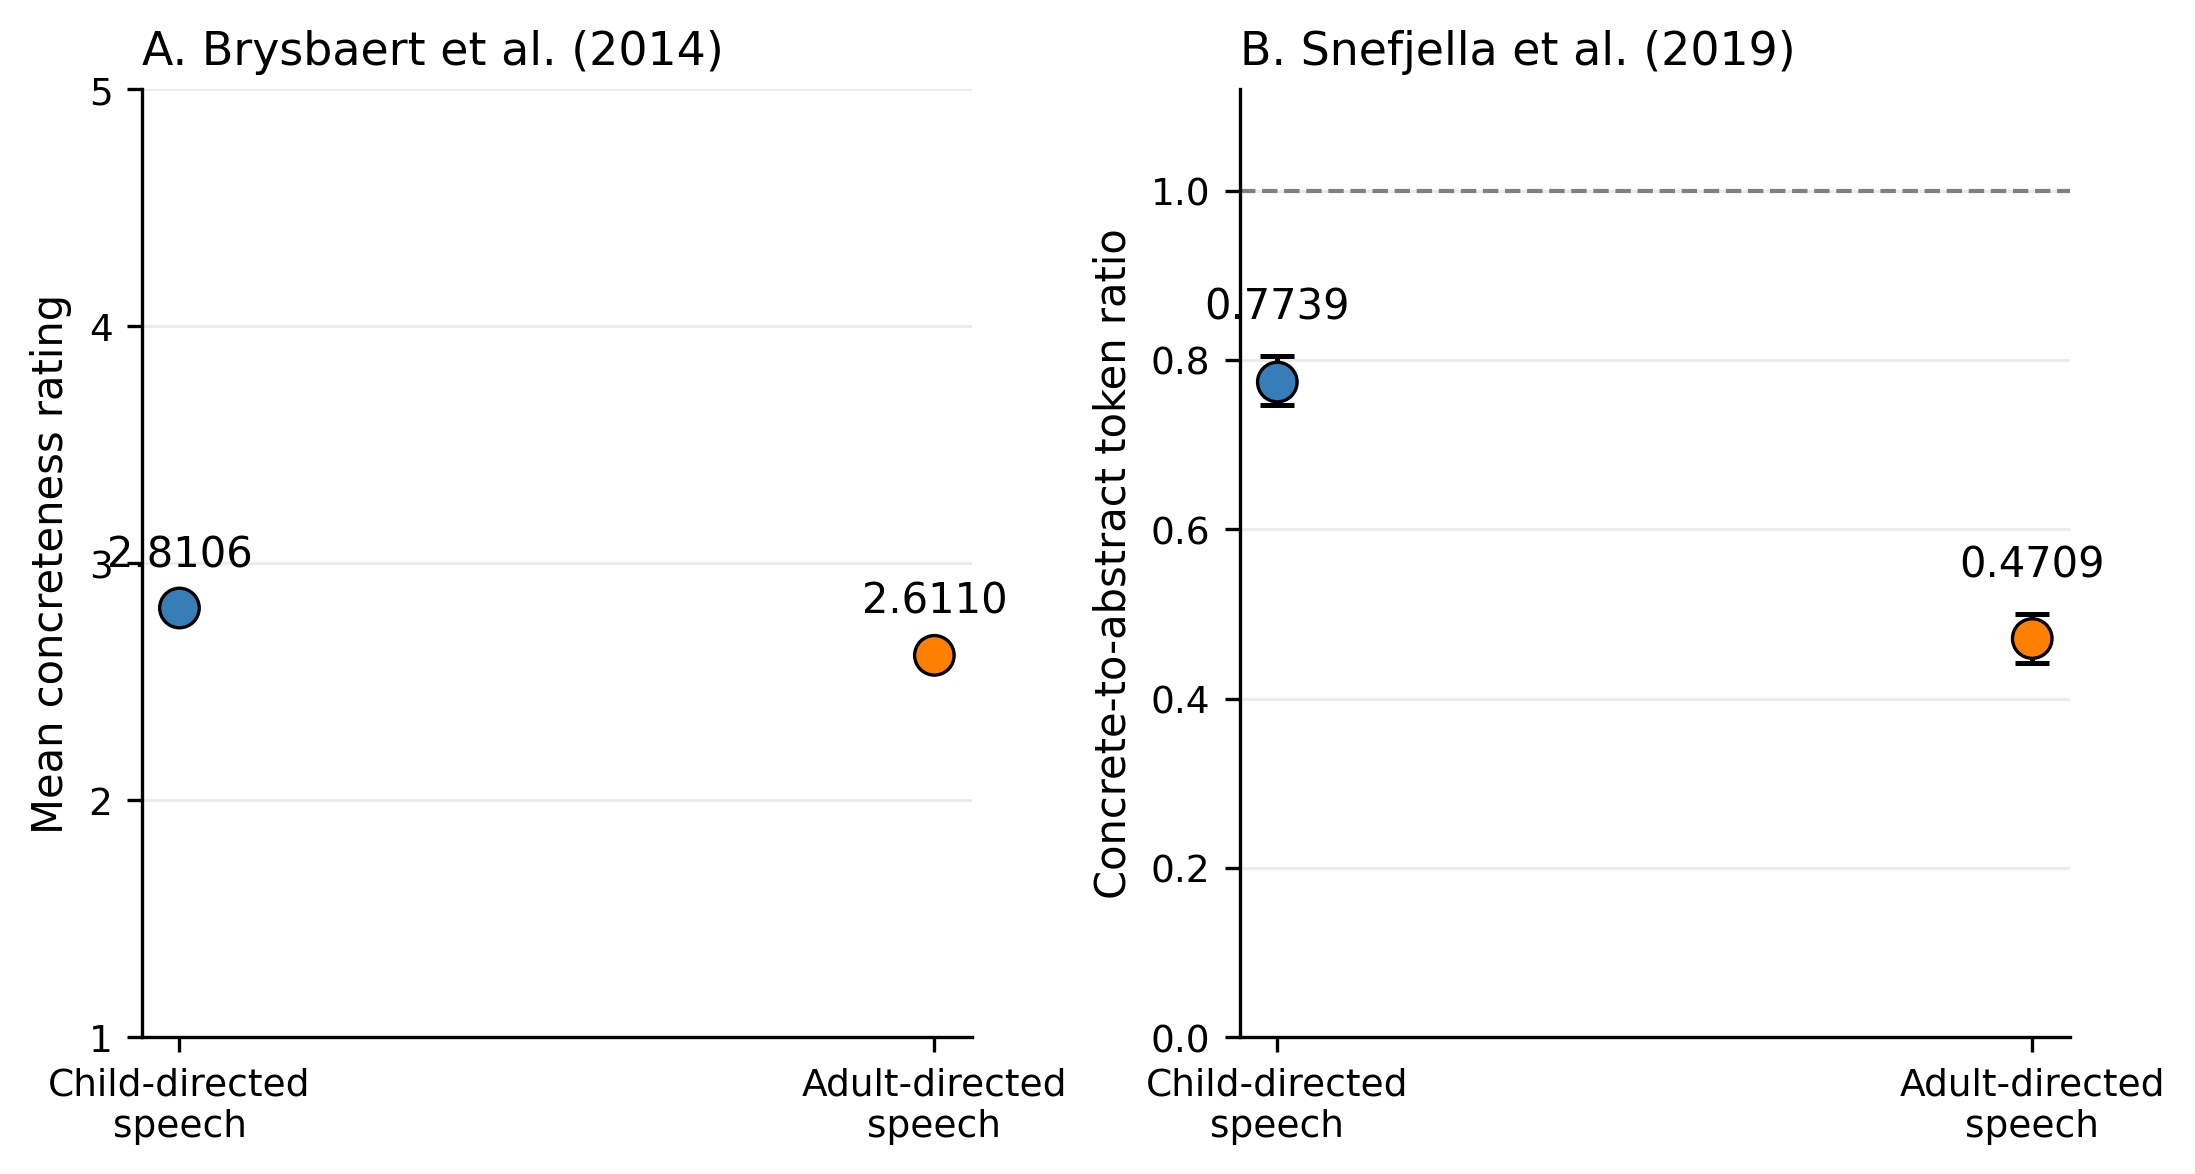


--- Cluster-bootstrap results ---
CDS Brysbaert: 2.8106, 95% CI [2.7945, 2.8245] (14 child clusters)
ADS Brysbaert: 2.6110, 95% CI [2.5897, 2.6308] (255 file clusters)
CDS SocialSent: 0.7739, 95% CI [0.7464, 0.8044] (14 child clusters)
ADS SocialSent: 0.4709, 95% CI [0.4414, 0.4994] (255 file clusters)

--- CDS–ADS contrasts ---
Brysbaert mean difference: 0.1997, 95% CI [0.1744, 0.2252]
SocialSent ratio difference: 0.3030, 95% CI [0.2627, 0.3436]

PDF saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.pdf
JPEG saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg


In [16]:
# --- Publication Plot: Concreteness in CDS vs ADS with 95% Bootstrap CIs ---

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ----------------------------------------------------------------------
# 1. Settings
# ----------------------------------------------------------------------

N_BOOTSTRAP = 10_000
CONFIDENCE_LEVEL = 0.95
RANDOM_SEED = 20260807

OUTPUT_DIRECTORY = Path(r"C:\Users\lvfeu\Desktop")
OUTPUT_STEM = "Concreteness_scores_2"


# ----------------------------------------------------------------------
# 2. Calculate sufficient statistics for every file
# ----------------------------------------------------------------------

def summarize_concreteness_by_file(analysis_result):
    """
    Calculate the information required for the two token-level metrics
    separately for every file.

    Brysbaert:
        sum of token ratings and number of rated tokens

    SocialSent:
        numbers of concrete and abstract rated tokens
    """
    rows = []

    for filename, lemmas in sorted(
        analysis_result["lemmas_by_file"].items()
    ):
        brysbaert_result = score_brysbaert(lemmas)
        socialsent_result = score_socialsent(lemmas)

        rows.append({
            "filename": filename,

            "brysbaert_sum": float(
                np.sum(brysbaert_result["scores"])
            ),
            "brysbaert_n": len(
                brysbaert_result["scores"]
            ),

            "socialsent_concrete": int(
                socialsent_result["counts"].get(1, 0)
            ),
            "socialsent_abstract": int(
                socialsent_result["counts"].get(-1, 0)
            )
        })

    file_summary = pd.DataFrame(rows)

    if file_summary.empty:
        raise ValueError(
            "No files were found in analysis_result['lemmas_by_file']."
        )

    if file_summary["brysbaert_n"].sum() == 0:
        raise ValueError(
            "No Brysbaert-rated tokens were found."
        )

    if file_summary["socialsent_abstract"].sum() == 0:
        raise ValueError(
            "No abstract SocialSent tokens were found, "
            "so the concrete-to-abstract ratio is undefined."
        )

    return file_summary


# ----------------------------------------------------------------------
# 3. Assign files to bootstrap clusters
# ----------------------------------------------------------------------

def create_cluster_summary(
    analysis_result,
    metadata=None,
    cluster_column=None
):
    """
    Aggregate file statistics into independent bootstrap clusters.

    For CDS, metadata=df_cds and cluster_column='name' cause all files
    belonging to the same child to remain in the same cluster.

    For ADS, metadata and cluster_column are omitted, so each file is
    treated as one cluster.
    """
    file_summary = summarize_concreteness_by_file(
        analysis_result
    )

    if metadata is not None and cluster_column is not None:
        required_columns = {"filename", cluster_column}

        if not required_columns.issubset(metadata.columns):
            missing = required_columns - set(metadata.columns)

            raise KeyError(
                f"Missing metadata columns: {sorted(missing)}"
            )

        cluster_lookup = (
            metadata[["filename", cluster_column]]
            .drop_duplicates(subset="filename")
            .set_index("filename")[cluster_column]
            .to_dict()
        )

        def identify_cluster(filename):
            cluster = cluster_lookup.get(filename)

            # If the subject cannot be identified, keep that file as
            # a separate cluster rather than combining all unknown files.
            if (
                cluster is None
                or pd.isna(cluster)
                or str(cluster).strip() in {"", "Unknown"}
            ):
                return f"file::{filename}"

            return str(cluster)

        file_summary["cluster"] = (
            file_summary["filename"].map(identify_cluster)
        )

    else:
        # Each ADS file is treated as an independent cluster.
        file_summary["cluster"] = file_summary["filename"]

    cluster_summary = (
        file_summary
        .groupby("cluster", as_index=False, sort=True)[
            [
                "brysbaert_sum",
                "brysbaert_n",
                "socialsent_concrete",
                "socialsent_abstract"
            ]
        ]
        .sum()
    )

    if len(cluster_summary) < 2:
        raise ValueError(
            "At least two independent clusters are required "
            "for bootstrap confidence intervals."
        )

    return cluster_summary


# ----------------------------------------------------------------------
# 4. Cluster-bootstrap confidence intervals
# ----------------------------------------------------------------------

def cluster_bootstrap_metrics(
    cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260807
):
    """
    Resample complete clusters with replacement.

    Estimates remain token-weighted because the token sums and counts
    from each selected cluster are pooled in every bootstrap sample.
    """
    brysbaert_sum = cluster_summary[
        "brysbaert_sum"
    ].to_numpy(dtype=float)

    brysbaert_n = cluster_summary[
        "brysbaert_n"
    ].to_numpy(dtype=float)

    socialsent_concrete = cluster_summary[
        "socialsent_concrete"
    ].to_numpy(dtype=float)

    socialsent_abstract = cluster_summary[
        "socialsent_abstract"
    ].to_numpy(dtype=float)

    n_clusters = len(cluster_summary)

    # Observed corpus-level estimates
    brysbaert_estimate = (
        brysbaert_sum.sum() / brysbaert_n.sum()
    )

    socialsent_estimate = (
        socialsent_concrete.sum()
        / socialsent_abstract.sum()
    )

    rng = np.random.default_rng(seed)

    brysbaert_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    socialsent_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    equal_cluster_probabilities = np.full(
        n_clusters,
        1 / n_clusters
    )

    for bootstrap_index in range(n_bootstrap):
        # Equivalent to drawing n_clusters cluster names with replacement.
        cluster_weights = rng.multinomial(
            n_clusters,
            equal_cluster_probabilities
        )

        sampled_brysbaert_n = float(
            cluster_weights @ brysbaert_n
        )

        sampled_socialsent_abstract = float(
            cluster_weights @ socialsent_abstract
        )

        if sampled_brysbaert_n > 0:
            brysbaert_bootstrap[bootstrap_index] = (
                float(cluster_weights @ brysbaert_sum)
                / sampled_brysbaert_n
            )

        if sampled_socialsent_abstract > 0:
            socialsent_bootstrap[bootstrap_index] = (
                float(cluster_weights @ socialsent_concrete)
                / sampled_socialsent_abstract
            )

    alpha = 1 - confidence_level

    quantiles = [
        alpha / 2,
        1 - alpha / 2
    ]

    valid_brysbaert = brysbaert_bootstrap[
        np.isfinite(brysbaert_bootstrap)
    ]

    valid_socialsent = socialsent_bootstrap[
        np.isfinite(socialsent_bootstrap)
    ]

    if len(valid_brysbaert) == 0:
        raise ValueError(
            "No valid Brysbaert bootstrap samples were produced."
        )

    if len(valid_socialsent) == 0:
        raise ValueError(
            "No valid SocialSent bootstrap samples were produced."
        )

    brysbaert_ci = tuple(
        np.quantile(valid_brysbaert, quantiles)
    )

    socialsent_ci = tuple(
        np.quantile(valid_socialsent, quantiles)
    )

    return {
        "n_clusters": n_clusters,

        "brysbaert_estimate": float(
            brysbaert_estimate
        ),
        "brysbaert_ci": brysbaert_ci,
        "brysbaert_bootstrap": brysbaert_bootstrap,

        "socialsent_estimate": float(
            socialsent_estimate
        ),
        "socialsent_ci": socialsent_ci,
        "socialsent_bootstrap": socialsent_bootstrap
    }


# ----------------------------------------------------------------------
# 5. Create CDS and ADS cluster summaries
# ----------------------------------------------------------------------

# CDS: resample children, keeping all files from each child together.
cds_cluster_summary = create_cluster_summary(
    analysis_result=cds_conc,
    metadata=df_cds,
    cluster_column="name"
)

# ADS: resample complete files.
ads_cluster_summary = create_cluster_summary(
    analysis_result=ads_conc
)


# ----------------------------------------------------------------------
# 6. Run the bootstrap
# ----------------------------------------------------------------------

cds_bootstrap_results = cluster_bootstrap_metrics(
    cluster_summary=cds_cluster_summary,
    n_bootstrap=N_BOOTSTRAP,
    confidence_level=CONFIDENCE_LEVEL,
    seed=RANDOM_SEED
)

ads_bootstrap_results = cluster_bootstrap_metrics(
    cluster_summary=ads_cluster_summary,
    n_bootstrap=N_BOOTSTRAP,
    confidence_level=CONFIDENCE_LEVEL,
    seed=RANDOM_SEED + 1
)


# ----------------------------------------------------------------------
# 7. Extract estimates and confidence intervals
# ----------------------------------------------------------------------

brysbaert_values = np.array([
    cds_bootstrap_results["brysbaert_estimate"],
    ads_bootstrap_results["brysbaert_estimate"]
])

brysbaert_cis = [
    cds_bootstrap_results["brysbaert_ci"],
    ads_bootstrap_results["brysbaert_ci"]
]

socialsent_values = np.array([
    cds_bootstrap_results["socialsent_estimate"],
    ads_bootstrap_results["socialsent_estimate"]
])

socialsent_cis = [
    cds_bootstrap_results["socialsent_ci"],
    ads_bootstrap_results["socialsent_ci"]
]


def asymmetric_error_lengths(estimates, intervals):
    """
    Convert lower and upper CI limits into the error lengths expected
    by Matplotlib.
    """
    estimates = np.asarray(estimates, dtype=float)

    lower_limits = np.asarray(
        [interval[0] for interval in intervals],
        dtype=float
    )

    upper_limits = np.asarray(
        [interval[1] for interval in intervals],
        dtype=float
    )

    return np.vstack([
        estimates - lower_limits,
        upper_limits - estimates
    ])


# ----------------------------------------------------------------------
# 8. Calculate CDS–ADS contrasts and their bootstrap CIs
# ----------------------------------------------------------------------

def percentile_ci(values, confidence_level=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    alpha = 1 - confidence_level

    return tuple(
        np.quantile(
            values,
            [alpha / 2, 1 - alpha / 2]
        )
    )


brysbaert_difference = (
    brysbaert_values[0] - brysbaert_values[1]
)

brysbaert_difference_bootstrap = (
    cds_bootstrap_results["brysbaert_bootstrap"]
    - ads_bootstrap_results["brysbaert_bootstrap"]
)

brysbaert_difference_ci = percentile_ci(
    brysbaert_difference_bootstrap,
    CONFIDENCE_LEVEL
)

socialsent_difference = (
    socialsent_values[0] - socialsent_values[1]
)

socialsent_difference_bootstrap = (
    cds_bootstrap_results["socialsent_bootstrap"]
    - ads_bootstrap_results["socialsent_bootstrap"]
)

socialsent_difference_ci = percentile_ci(
    socialsent_difference_bootstrap,
    CONFIDENCE_LEVEL
)


# ----------------------------------------------------------------------
# 9. Plot setup
# ----------------------------------------------------------------------

labels = [
    "Child-directed\nspeech",
    "Adult-directed\nspeech"
]

x = np.arange(len(labels))

colors = [
    "#377eb8",
    "#ff7f00"
]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.8),
    dpi=300,
    constrained_layout=True
)


# ----------------------------------------------------------------------
# 10. Panel A: Brysbaert ratings
# ----------------------------------------------------------------------

axes[0].errorbar(
    x,
    brysbaert_values,
    yerr=asymmetric_error_lengths(
        brysbaert_values,
        brysbaert_cis
    ),
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
    capthick=1.2,
    zorder=2
)

axes[0].scatter(
    x,
    brysbaert_values,
    s=90,
    c=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

axes[0].set_title(
    "A. Brysbaert et al. (2014)",
    loc="left"
)

axes[0].set_ylabel(
    "Mean concreteness rating"
)

axes[0].set_xticks(
    x,
    labels
)

# Display the complete theoretical Brysbaert scale.
axes[0].set_ylim(1, 5)
axes[0].set_yticks([1, 2, 3, 4, 5])

for xi, value, interval in zip(
    x,
    brysbaert_values,
    brysbaert_cis
):
    axes[0].annotate(
        f"{value:.4f}",
        (xi, interval[1]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )


# ----------------------------------------------------------------------
# 11. Panel B: SocialSent ratio
# ----------------------------------------------------------------------

axes[1].errorbar(
    x,
    socialsent_values,
    yerr=asymmetric_error_lengths(
        socialsent_values,
        socialsent_cis
    ),
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
    capthick=1.2,
    zorder=2
)

axes[1].scatter(
    x,
    socialsent_values,
    s=90,
    c=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

axes[1].set_title(
    "B. Snefjella et al. (2019)",
    loc="left"
)

axes[1].set_ylabel(
    "Concrete-to-abstract token ratio"
)

axes[1].set_xticks(
    x,
    labels
)

# A ratio of 1 means equal concrete and abstract token counts.
axes[1].axhline(
    1,
    color="grey",
    linestyle="--",
    linewidth=1,
    zorder=1
)

socialsent_upper_limit = max(
    1,
    brysbaert_values.min() * 0,
    *(interval[1] for interval in socialsent_cis)
)

axes[1].set_ylim(
    0,
    socialsent_upper_limit * 1.12
)

for xi, value, interval in zip(
    x,
    socialsent_values,
    socialsent_cis
):
    axes[1].annotate(
        f"{value:.4f}",
        (xi, interval[1]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )


# ----------------------------------------------------------------------
# 12. Shared formatting
# ----------------------------------------------------------------------

for ax in axes:
    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.7
    )
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ----------------------------------------------------------------------
# 13. Save PDF and JPEG
# ----------------------------------------------------------------------

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

pdf_path = (
    OUTPUT_DIRECTORY
    / f"{OUTPUT_STEM}.pdf"
)

jpeg_path = (
    OUTPUT_DIRECTORY
    / f"{OUTPUT_STEM}.jpg"
)

fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    jpeg_path,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ----------------------------------------------------------------------
# 14. Print publication-ready results
# ----------------------------------------------------------------------

confidence_percentage = int(
    CONFIDENCE_LEVEL * 100
)

print("\n--- Cluster-bootstrap results ---")

print(
    f"CDS Brysbaert: "
    f"{brysbaert_values[0]:.4f}, "
    f"{confidence_percentage}% CI "
    f"[{brysbaert_cis[0][0]:.4f}, "
    f"{brysbaert_cis[0][1]:.4f}] "
    f"({cds_bootstrap_results['n_clusters']} child clusters)"
)

print(
    f"ADS Brysbaert: "
    f"{brysbaert_values[1]:.4f}, "
    f"{confidence_percentage}% CI "
    f"[{brysbaert_cis[1][0]:.4f}, "
    f"{brysbaert_cis[1][1]:.4f}] "
    f"({ads_bootstrap_results['n_clusters']} file clusters)"
)

print(
    f"CDS SocialSent: "
    f"{socialsent_values[0]:.4f}, "
    f"{confidence_percentage}% CI "
    f"[{socialsent_cis[0][0]:.4f}, "
    f"{socialsent_cis[0][1]:.4f}] "
    f"({cds_bootstrap_results['n_clusters']} child clusters)"
)

print(
    f"ADS SocialSent: "
    f"{socialsent_values[1]:.4f}, "
    f"{confidence_percentage}% CI "
    f"[{socialsent_cis[1][0]:.4f}, "
    f"{socialsent_cis[1][1]:.4f}] "
    f"({ads_bootstrap_results['n_clusters']} file clusters)"
)

print("\n--- CDS–ADS contrasts ---")

print(
    f"Brysbaert mean difference: "
    f"{brysbaert_difference:.4f}, "
    f"{confidence_percentage}% CI "
    f"[{brysbaert_difference_ci[0]:.4f}, "
    f"{brysbaert_difference_ci[1]:.4f}]"
)

print(
    f"SocialSent ratio difference: "
    f"{socialsent_difference:.4f}, "
    f"{confidence_percentage}% CI "
    f"[{socialsent_difference_ci[0]:.4f}, "
    f"{socialsent_difference_ci[1]:.4f}]"
)

print(f"\nPDF saved to: {pdf_path}")
print(f"JPEG saved to: {jpeg_path}")

In [24]:
# --- Plot Concreteness: CDS vs ADS on a Common Theoretical 0–1 Scale ---

import os
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.font_manager import FontProperties


# -----------------------------
# 1. Settings
# -----------------------------

N_BOOTSTRAP = 10_000
CONFIDENCE_LEVEL = 0.95
RANDOM_SEED = 20260807


# -----------------------------
# 2. Extract raw values
# -----------------------------

# Brysbaert continuous token-level means
brysbaert_cds = np.mean(scores_CDS_tok)
brysbaert_ads = np.mean(scores_Spok_tok)

# SocialSent concrete-to-abstract token ratios
socialsent_cds = (
    cds_conc["socialsent_tokens"]
    ["concrete_to_abstract_ratio"]
)

socialsent_ads = (
    ads_conc["socialsent_tokens"]
    ["concrete_to_abstract_ratio"]
)

brysbaert_values = np.array([
    brysbaert_cds,
    brysbaert_ads
])

socialsent_values = np.array([
    socialsent_cds,
    socialsent_ads
])


# -----------------------------
# 3. Print raw values
# -----------------------------

print("--- Raw values ---")

print(
    f"CDS Brysbaert token mean: "
    f"{brysbaert_cds:.4f}"
)

print(
    f"ADS Brysbaert token mean: "
    f"{brysbaert_ads:.4f}"
)

print(
    f"CDS SocialSent concrete/abstract ratio: "
    f"{socialsent_cds:.4f}"
)

print(
    f"ADS SocialSent concrete/abstract ratio: "
    f"{socialsent_ads:.4f}"
)


# -----------------------------
# 4. Cache dictionary lookups
# -----------------------------

# Caching prevents repeated dictionary searches for the same lemma.

@lru_cache(maxsize=None)
def cached_brysbaert_score(lemma):
    score, matched_word = lookup_brysbaert(lemma)
    return score


@lru_cache(maxsize=None)
def cached_socialsent_score(lemma):
    score, matched_word = lookup_socialsent(lemma)
    return score


# -----------------------------
# 5. Calculate statistics by file
# -----------------------------

def summarize_concreteness_by_file(analysis_result):
    """
    Calculate the information required for the two token-level
    concreteness measures separately for every file.
    """
    rows = []

    for filename, lemmas in sorted(
        analysis_result["lemmas_by_file"].items()
    ):
        brysbaert_sum = 0.0
        brysbaert_n = 0

        socialsent_concrete = 0
        socialsent_abstract = 0

        for lemma in lemmas:
            brysbaert_score = cached_brysbaert_score(
                lemma
            )

            if brysbaert_score is not None:
                brysbaert_sum += brysbaert_score
                brysbaert_n += 1

            socialsent_score = cached_socialsent_score(
                lemma
            )

            if socialsent_score == 1:
                socialsent_concrete += 1

            elif socialsent_score == -1:
                socialsent_abstract += 1

        rows.append({
            "filename": filename,
            "brysbaert_sum": brysbaert_sum,
            "brysbaert_n": brysbaert_n,
            "socialsent_concrete": socialsent_concrete,
            "socialsent_abstract": socialsent_abstract
        })

    file_summary = pd.DataFrame(rows)

    if file_summary.empty:
        raise ValueError(
            "No files were found in lemmas_by_file."
        )

    if file_summary["brysbaert_n"].sum() == 0:
        raise ValueError(
            "No Brysbaert-rated tokens were found."
        )

    if (
        file_summary["socialsent_abstract"].sum()
        == 0
    ):
        raise ValueError(
            "No abstract SocialSent tokens were found."
        )

    return file_summary


cds_file_summary = summarize_concreteness_by_file(
    cds_conc
)

ads_file_summary = summarize_concreteness_by_file(
    ads_conc
)


# -----------------------------
# 6. Define independent clusters
# -----------------------------

# For CDS, all recordings belonging to the same child
# remain together in one bootstrap cluster.

cds_subject_lookup = (
    df_cds[["filename", "name"]]
    .drop_duplicates(subset="filename")
    .set_index("filename")["name"]
    .to_dict()
)


def identify_cds_cluster(filename):
    subject = cds_subject_lookup.get(filename)

    if (
        subject is None
        or pd.isna(subject)
        or str(subject).strip() in {"", "Unknown"}
    ):
        # Keep an unidentified file as its own cluster.
        return f"file::{filename}"

    return str(subject)


cds_file_summary["cluster"] = (
    cds_file_summary["filename"]
    .map(identify_cds_cluster)
)

# For ADS, each complete file is one bootstrap cluster.
ads_file_summary["cluster"] = (
    ads_file_summary["filename"]
)


# -----------------------------
# 7. Aggregate files by cluster
# -----------------------------

def aggregate_by_cluster(file_summary):
    return (
        file_summary
        .groupby(
            "cluster",
            as_index=False,
            sort=True
        )[
            [
                "brysbaert_sum",
                "brysbaert_n",
                "socialsent_concrete",
                "socialsent_abstract"
            ]
        ]
        .sum()
    )


cds_cluster_summary = aggregate_by_cluster(
    cds_file_summary
)

ads_cluster_summary = aggregate_by_cluster(
    ads_file_summary
)

print(
    f"\nCDS bootstrap clusters: "
    f"{len(cds_cluster_summary)}"
)

print(
    f"ADS bootstrap clusters: "
    f"{len(ads_cluster_summary)}"
)


# -----------------------------
# 8. Cluster-bootstrap CIs
# -----------------------------

def cluster_bootstrap_cis(
    cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260807
):
    """
    Resample complete clusters with replacement and calculate
    percentile confidence intervals for both raw measures.
    """
    brysbaert_sum = cluster_summary[
        "brysbaert_sum"
    ].to_numpy(dtype=float)

    brysbaert_n = cluster_summary[
        "brysbaert_n"
    ].to_numpy(dtype=float)

    socialsent_concrete = cluster_summary[
        "socialsent_concrete"
    ].to_numpy(dtype=float)

    socialsent_abstract = cluster_summary[
        "socialsent_abstract"
    ].to_numpy(dtype=float)

    n_clusters = len(cluster_summary)

    if n_clusters < 2:
        raise ValueError(
            "At least two independent clusters are required."
        )

    rng = np.random.default_rng(seed)

    brysbaert_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    socialsent_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    cluster_probabilities = np.full(
        n_clusters,
        1 / n_clusters
    )

    for bootstrap_index in range(n_bootstrap):
        # Sample n_clusters complete clusters with replacement.
        cluster_weights = rng.multinomial(
            n_clusters,
            cluster_probabilities
        )

        sampled_brysbaert_n = float(
            cluster_weights @ brysbaert_n
        )

        sampled_abstract_n = float(
            cluster_weights @ socialsent_abstract
        )

        if sampled_brysbaert_n > 0:
            brysbaert_bootstrap[bootstrap_index] = (
                float(
                    cluster_weights
                    @ brysbaert_sum
                )
                / sampled_brysbaert_n
            )

        if sampled_abstract_n > 0:
            socialsent_bootstrap[bootstrap_index] = (
                float(
                    cluster_weights
                    @ socialsent_concrete
                )
                / sampled_abstract_n
            )

    valid_brysbaert = brysbaert_bootstrap[
        np.isfinite(brysbaert_bootstrap)
    ]

    valid_socialsent = socialsent_bootstrap[
        np.isfinite(socialsent_bootstrap)
    ]

    alpha = 1 - confidence_level

    quantiles = [
        alpha / 2,
        1 - alpha / 2
    ]

    brysbaert_ci = tuple(
        np.quantile(
            valid_brysbaert,
            quantiles
        )
    )

    socialsent_ci = tuple(
        np.quantile(
            valid_socialsent,
            quantiles
        )
    )

    return {
        "brysbaert_ci": brysbaert_ci,
        "socialsent_ci": socialsent_ci
    }


cds_bootstrap_results = cluster_bootstrap_cis(
    cds_cluster_summary,
    n_bootstrap=N_BOOTSTRAP,
    confidence_level=CONFIDENCE_LEVEL,
    seed=RANDOM_SEED
)

ads_bootstrap_results = cluster_bootstrap_cis(
    ads_cluster_summary,
    n_bootstrap=N_BOOTSTRAP,
    confidence_level=CONFIDENCE_LEVEL,
    seed=RANDOM_SEED + 1
)


# -----------------------------
# 9. Raw confidence intervals
# -----------------------------

brysbaert_cis = [
    cds_bootstrap_results["brysbaert_ci"],
    ads_bootstrap_results["brysbaert_ci"]
]

socialsent_cis = [
    cds_bootstrap_results["socialsent_ci"],
    ads_bootstrap_results["socialsent_ci"]
]


# -----------------------------
# 10. Theoretical 0–1 rescaling
# -----------------------------

# Brysbaert ratings range from 1 to 5:
#
#     normalized = (rating - 1) / (5 - 1)
#
# Therefore, 1 maps to 0 and 5 maps to 1.

brysbaert_rescaled = (
    (brysbaert_values - 1) / 4
)


# SocialSent ratios are converted to the proportion concrete
# among concrete and abstract tokens:
#
#     proportion = ratio / (1 + ratio)
#
# Therefore, a ratio of 0 maps to 0 and increasingly concrete
# ratios approach 1.

socialsent_rescaled = (
    socialsent_values
    / (1 + socialsent_values)
)


# Apply the same monotonic transformations to CI endpoints.

brysbaert_rescaled_cis = [
    (
        (interval[0] - 1) / 4,
        (interval[1] - 1) / 4
    )
    for interval in brysbaert_cis
]

socialsent_rescaled_cis = [
    (
        interval[0] / (1 + interval[0]),
        interval[1] / (1 + interval[1])
    )
    for interval in socialsent_cis
]


# -----------------------------
# 11. Convert CIs to error lengths
# -----------------------------

def make_error_bars(
    values,
    confidence_intervals
):
    lower_errors = [
        max(0, value - interval[0])
        for value, interval in zip(
            values,
            confidence_intervals
        )
    ]

    upper_errors = [
        max(0, interval[1] - value)
        for value, interval in zip(
            values,
            confidence_intervals
        )
    ]

    return np.array([
        lower_errors,
        upper_errors
    ])


brysbaert_errors = make_error_bars(
    brysbaert_rescaled,
    brysbaert_rescaled_cis
)

socialsent_errors = make_error_bars(
    socialsent_rescaled,
    socialsent_rescaled_cis
)


# -----------------------------
# 12. Print rescaled values
# -----------------------------

print("\n--- Values rescaled to 0–1 ---")

print(
    f"CDS Brysbaert: "
    f"{brysbaert_rescaled[0]:.4f}"
)

print(
    f"ADS Brysbaert: "
    f"{brysbaert_rescaled[1]:.4f}"
)

print(
    f"CDS SocialSent: "
    f"{socialsent_rescaled[0]:.4f}"
)

print(
    f"ADS SocialSent: "
    f"{socialsent_rescaled[1]:.4f}"
)


# -----------------------------
# 13. Plot setup
# -----------------------------

labels = [
    "Child-directed speech",
    "Adult-directed speech"
]

x = np.arange(len(labels))
width = 0.32

colors = [
    "#377eb8",
    "#ff7f00"
]


# Optional Helvetica font

personal_path = (
    r"C:\Users\lvfeu\Desktop\PhD\University of Zurich\Paper 2"
    r"\Metaphor Identification Corpus 3 modalities"
)

font_path = os.path.join(
    personal_path,
    "helveticaneue.ttf"
)

if os.path.exists(font_path):
    axis_font = FontProperties(
        fname=font_path,
        size=24
    )

    label_font = FontProperties(
        fname=font_path,
        size=28
    )

    title_font = FontProperties(
        fname=font_path,
        size=33
    )

    legend_font = FontProperties(
        fname=font_path,
        size=22
    )

else:
    axis_font = FontProperties(
        family="Helvetica",
        size=24
    )

    label_font = FontProperties(
        family="Helvetica",
        size=28
    )

    title_font = FontProperties(
        family="Helvetica",
        size=33
    )

    legend_font = FontProperties(
        family="Helvetica",
        size=22
    )


# -----------------------------
# 14. Draw one-panel bar chart
# -----------------------------

fig, ax = plt.subplots(
    figsize=(20, 17),
    dpi=600
)

bars1 = ax.bar(
    x - width / 2,
    brysbaert_rescaled,
    width,
    yerr=brysbaert_errors,
    capsize=8,
    color=colors[0],
    edgecolor="black",
    linewidth=1.2,
    error_kw={
        "elinewidth": 2,
        "capthick": 2,
        "ecolor": "black"
    },
    label=(
        "Brysbaert et al. (2014): "
        "rescaled mean rating"
    )
)

bars2 = ax.bar(
    x + width / 2,
    socialsent_rescaled,
    width,
    yerr=socialsent_errors,
    capsize=8,
    color=colors[1],
    edgecolor="black",
    linewidth=1.2,
    error_kw={
        "elinewidth": 2,
        "capthick": 2,
        "ecolor": "black"
    },
    label=(
        "Snefjella et al. (2019): "
        "proportion concrete"
    )
)


# -----------------------------
# 15. Add values above bars
# -----------------------------

# Each label shows:
# line 1 = value on the common 0–1 scale
# line 2 = original untransformed value

for bar, rescaled_value, raw_value, interval in zip(
    bars1,
    brysbaert_rescaled,
    brysbaert_values,
    brysbaert_rescaled_cis
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        interval[1] + 0.025,
        (
            f"{rescaled_value:.3f}\n"
            f"(raw {raw_value:.2f})"
        ),
        ha="center",
        va="bottom",
        fontproperties=axis_font,
        linespacing=1.2
    )

for bar, rescaled_value, raw_value, interval in zip(
    bars2,
    socialsent_rescaled,
    socialsent_values,
    socialsent_rescaled_cis
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        interval[1] + 0.025,
        (
            f"{rescaled_value:.3f}\n"
            f"(raw {raw_value:.2f})"
        ),
        ha="center",
        va="bottom",
        fontproperties=axis_font,
        linespacing=1.2
    )


# -----------------------------
# 16. Labels and formatting
# -----------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    labels,
    fontproperties=axis_font
)

ax.set_yticks(
    np.arange(0, 1.01, 0.1)
)

for tick_label in ax.get_yticklabels():
    tick_label.set_fontproperties(
        axis_font
    )

ax.set_ylabel(
    "Concreteness measure rescaled to 0–1",
    fontproperties=label_font
)

ax.set_title(
    "Concreteness Scores across Spoken Registers",
    fontproperties=title_font,
    pad=25
)

ax.legend(
    prop=legend_font,
    loc="upper right"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.set_ylim(
    0,
    1.05
)

ax.margins(
    x=0.15
)

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

plt.subplots_adjust(
    bottom=0.15,
    left=0.12,
    right=0.96,
    top=0.90
)


# -----------------------------
# 17. Save PDF and JPEG
# -----------------------------

output_jpeg_path = (
    r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg"
)

output_pdf_path = (
    r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.pdf"
)

fig.savefig(
    output_jpeg_path,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    output_pdf_path,
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# -----------------------------
# 18. Print estimates and CIs
# -----------------------------

print(
    "\n--- Rescaled values and "
    "95% cluster-bootstrap CIs ---"
)

print(
    f"CDS Brysbaert: "
    f"{brysbaert_rescaled[0]:.4f}, "
    f"95% CI "
    f"[{brysbaert_rescaled_cis[0][0]:.4f}, "
    f"{brysbaert_rescaled_cis[0][1]:.4f}]"
)

print(
    f"ADS Brysbaert: "
    f"{brysbaert_rescaled[1]:.4f}, "
    f"95% CI "
    f"[{brysbaert_rescaled_cis[1][0]:.4f}, "
    f"{brysbaert_rescaled_cis[1][1]:.4f}]"
)

print(
    f"CDS SocialSent: "
    f"{socialsent_rescaled[0]:.4f}, "
    f"95% CI "
    f"[{socialsent_rescaled_cis[0][0]:.4f}, "
    f"{socialsent_rescaled_cis[0][1]:.4f}]"
)

print(
    f"ADS SocialSent: "
    f"{socialsent_rescaled[1]:.4f}, "
    f"95% CI "
    f"[{socialsent_rescaled_cis[1][0]:.4f}, "
    f"{socialsent_rescaled_cis[1][1]:.4f}]"
)

print(
    f"\nJPEG saved to: "
    f"{output_jpeg_path}"
)

print(
    f"PDF saved to: "
    f"{output_pdf_path}"
)

--- Raw values ---
CDS Brysbaert token mean: 2.8106
ADS Brysbaert token mean: 2.6110
CDS SocialSent concrete/abstract ratio: 0.7739
ADS SocialSent concrete/abstract ratio: 0.4709

CDS bootstrap clusters: 14
ADS bootstrap clusters: 255

--- Values rescaled to 0–1 ---
CDS Brysbaert: 0.4527
ADS Brysbaert: 0.4027
CDS SocialSent: 0.4363
ADS SocialSent: 0.3201


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped



--- Rescaled values and 95% cluster-bootstrap CIs ---
CDS Brysbaert: 0.4527, 95% CI [0.4486, 0.4561]
ADS Brysbaert: 0.4027, 95% CI [0.3974, 0.4077]
CDS SocialSent: 0.4363, 95% CI [0.4274, 0.4458]
ADS SocialSent: 0.3201, 95% CI [0.3063, 0.3331]

JPEG saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg
PDF saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.pdf


In [20]:
# --- Plot Concreteness: CDS vs ADS, Two Concreteness Rating Datasets ---

import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.font_manager import FontProperties

# -----------------------------
# 1. Extract updated values
# -----------------------------

# Brysbaert continuous token-level means
brysbaert_cds = np.mean(scores_CDS_tok)
brysbaert_ads = np.mean(scores_Spok_tok)

# SocialSent concrete-to-abstract token ratios
socialsent_cds = cds_conc["socialsent_tokens"]["concrete_to_abstract_ratio"]
socialsent_ads = ads_conc["socialsent_tokens"]["concrete_to_abstract_ratio"]

# Raw values, for reference
print("--- Raw values ---")
print(f"CDS Brysbaert token mean: {brysbaert_cds:.4f}")
print(f"ADS Brysbaert token mean: {brysbaert_ads:.4f}")
print(f"CDS SocialSent concrete/abstract ratio: {socialsent_cds:.4f}")
print(f"ADS SocialSent concrete/abstract ratio: {socialsent_ads:.4f}")


# -----------------------------
# 2. Normalize separately for plotting
# -----------------------------
# This preserves relative CDS-vs-ADS differences within each measure.
# Each measure is scaled by its own maximum.

brysbaert_values = np.array([brysbaert_cds, brysbaert_ads])
socialsent_values = np.array([socialsent_cds, socialsent_ads])

brysbaert_norm = brysbaert_values / brysbaert_values.max()
socialsent_norm = socialsent_values / socialsent_values.max()


# -----------------------------
# 3. Plot setup
# -----------------------------

labels = ["Child-directed speech", "Adult-directed speech"]
x = np.arange(len(labels))

width = 0.32

colors = ["#377eb8", "#ff7f00"]

# Optional Helvetica font
personal_path = r"C:\Users\lvfeu\Desktop\PhD\University of Zurich\Paper 2\Metaphor Identification Corpus 3 modalities"
font_path = os.path.join(personal_path, "helveticaneue.ttf")

if os.path.exists(font_path):
    axis_font = FontProperties(fname=font_path, size=24)
    label_font = FontProperties(fname=font_path, size=28)
    title_font = FontProperties(fname=font_path, size=33)
    legend_font = FontProperties(fname=font_path, size=22)
else:
    axis_font = FontProperties(family="Helvetica", size=24)
    label_font = FontProperties(family="Helvetica", size=28)
    title_font = FontProperties(family="Helvetica", size=33)
    legend_font = FontProperties(family="Helvetica", size=22)


plt.figure(figsize=(20, 17), dpi=600)

bars1 = plt.bar(
    x - width / 2,
    brysbaert_norm,
    width,
    color=colors[0],
    edgecolor="black",
    label="Brysbaert et al. (2014): mean concreteness"
)

bars2 = plt.bar(
    x + width / 2,
    socialsent_norm,
    width,
    color=colors[1],
    edgecolor="black",
    label="Snefjella et al. (2019): concrete/abstract ratio"
)


# -----------------------------
# 4. Add raw-value labels above bars
# -----------------------------

for bar, raw_value in zip(bars1, brysbaert_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{raw_value:.2f}",
        ha="center",
        va="bottom",
        fontproperties=axis_font
    )

for bar, raw_value in zip(bars2, socialsent_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{raw_value:.2f}",
        ha="center",
        va="bottom",
        fontproperties=axis_font
    )


# -----------------------------
# 5. Labels and formatting
# -----------------------------

plt.xticks(x, labels, fontproperties=axis_font)
plt.yticks(fontproperties=axis_font)

plt.ylabel("Normalized concreteness values", fontproperties=label_font)

plt.title(
    "Normalized Concreteness Scores across Spoken Registers",
    fontproperties=title_font,
    pad=20
)

plt.legend(
    prop=legend_font,
    loc="upper right"
)

plt.grid(True, axis="y", alpha=0.3)

plt.ylim(0, 1.15)

plt.margins(0.15)
plt.subplots_adjust(bottom=0.15)

output_path = r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg"
plt.savefig(output_path, dpi=600, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {output_path}")

--- Raw values ---
CDS Brysbaert token mean: 2.8106
ADS Brysbaert token mean: 2.6110
CDS SocialSent concrete/abstract ratio: 0.7739
ADS SocialSent concrete/abstract ratio: 0.4709


Figure saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg


# ANOVAs

In [41]:
# For two registers only

import numpy as np
from scipy.stats import f_oneway, levene, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def run_two_group_anova(cds, ads, label):
    cds = np.asarray(cds, dtype=float)
    ads = np.asarray(ads, dtype=float)

    anova = f_oneway(cds, ads)
    df_between = 1
    df_within = len(cds) + len(ads) - 2

    print(f"\n{label}")
    print(f"CDS mean = {np.mean(cds):.3f}")
    print(f"ADS mean = {np.mean(ads):.3f}")
    print(f"F({df_between}, {df_within}) = {anova.statistic:.3f}, p = {anova.pvalue:.3e}")

    lev = levene(cds, ads)
    print(f"Levene test: W = {lev.statistic:.3f}, p = {lev.pvalue:.3e}")

    data = np.concatenate([ads, cds])
    groups = (["ADS"] * len(ads)) + (["CDS"] * len(cds))

    tukey = pairwise_tukeyhsd(endog=data, groups=groups, alpha=0.05)
    print(tukey)


run_two_group_anova(
    prop_met_tokens_CDS_100,
    prop_met_tokens_Spok_100,
    "Metaphorical tokens, window size 100"
)

run_two_group_anova(
    prop_met_types_CDS_100,
    prop_met_types_Spok_100,
    "Metaphorical types, window size 100"
)

run_two_group_anova(
    prop_met_tokens_CDS,
    prop_met_tokens_Spok,
    "Metaphorical tokens, window size 3"
)

run_two_group_anova(
    prop_met_types_CDS,
    prop_met_types_Spok,
    "Metaphorical types, window size 3"
)


Metaphorical tokens, window size 100
CDS mean = 5.768
ADS mean = 11.857
F(1, 868) = 1973.010, p = 1.052e-225
Levene test: W = 662.218, p = 5.602e-109
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper reject
-------------------------------------------------
   ADS    CDS  -6.0891   0.0 -6.3582 -5.82   True
-------------------------------------------------

Metaphorical types, window size 100
CDS mean = 10.463
ADS mean = 19.177
F(1, 868) = 1462.325, p = 2.467e-188
Levene test: W = 686.747, p = 5.579e-112
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   ADS    CDS  -8.7144   0.0 -9.1616 -8.2671   True
---------------------------------------------------

Metaphorical tokens, window size 3
CDS mean = 5.546
ADS mean = 8.983
F(1, 870) = 1201.023, p = 5.017e-166
Levene test: W = 366.527, p = 1.893e-68
Multiple Comparison of Means - Tukey HS

In [66]:
# --- ANOVAs: Continuous concreteness, CDS vs ADS ---
import numpy as np
import pandas as pd
from scipy import stats

def run_concreteness_anova(cds_scores, ads_scores, label):
    """
    Run one-way ANOVA comparing CDS and ADS concreteness scores.
    """

    cds_scores = np.asarray(cds_scores, dtype=float)
    ads_scores = np.asarray(ads_scores, dtype=float)

    # Remove NaNs if present
    cds_scores = cds_scores[~np.isnan(cds_scores)]
    ads_scores = ads_scores[~np.isnan(ads_scores)]

    # ANOVA
    anova = stats.f_oneway(cds_scores, ads_scores)

    # Degrees of freedom
    df_between = 1
    df_within = len(cds_scores) + len(ads_scores) - 2

    # Descriptives
    mean_cds = np.mean(cds_scores)
    mean_ads = np.mean(ads_scores)
    mean_diff = mean_cds - mean_ads

    print(f"\n--- {label}: CDS vs ADS ---")
    print(f"CDS N rated: {len(cds_scores)}")
    print(f"ADS N rated: {len(ads_scores)}")
    print(f"CDS mean: {mean_cds:.4f}")
    print(f"ADS mean: {mean_ads:.4f}")
    print(f"Mean difference, CDS - ADS: {mean_diff:.4f}")
    print(f"F({df_between}, {df_within}) = {anova.statistic:.3f}")
    print(f"p = {anova.pvalue:.4e}")

    return {
        "Level": label,
        "CDS_N": len(cds_scores),
        "ADS_N": len(ads_scores),
        "CDS_M": mean_cds,
        "ADS_M": mean_ads,
        "MD_CDS_minus_ADS": mean_diff,
        "F": anova.statistic,
        "df_between": df_between,
        "df_within": df_within,
        "p": anova.pvalue
    }


# --- Token-level ANOVA ---
anova_conc_tokens = run_concreteness_anova(
    scores_CDS_tok,
    scores_Spok_tok,
    "Token-level concreteness"
)

# --- Type-level ANOVA ---
anova_conc_types = run_concreteness_anova(
    scores_CDS_type,
    scores_Spok_type,
    "Type-level concreteness"
)

# --- Summary table ---
anova_concreteness_summary = pd.DataFrame([
    anova_conc_tokens,
    anova_conc_types
])

display(anova_concreteness_summary)


--- Token-level concreteness: CDS vs ADS ---
CDS N rated: 2533679
ADS N rated: 2891879
CDS mean: 2.8106
ADS mean: 2.6110
Mean difference, CDS - ADS: 0.1997
F(1, 5425556) = 48952.688
p = 0.0000e+00

--- Type-level concreteness: CDS vs ADS ---
CDS N rated: 7067
ADS N rated: 16304
CDS mean: 3.6314
ADS mean: 3.1783
Mean difference, CDS - ADS: 0.4530
F(1, 23369) = 925.737
p = 1.9268e-199


,Level,CDS_N,ADS_N,CDS_M,ADS_M,MD_CDS_minus_ADS,F,df_between,df_within,p
0,Token-level concreteness,2533679,2891879,2.810639,2.610989,0.199650,48952.687775,1,5425556,0.000000e+00
1,Type-level concreteness,7067,16304,3.631391,3.178347,0.453044,925.737430,1,23369,1.926761e-199


# Predicting Metaphor Proportions in CDS from Age

In [65]:
# --- Mixed-effects model: CDS metaphorical types predicted by child age ---
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Prepare model dataframe from df_cds
df_model_cds = df_cds[[
    "name",
    "age",
    "prop_met_types"
]].copy()

# Rename columns for clearer model formula
df_model_cds = df_model_cds.rename(columns={
    "name": "Name",
    "age": "Age",
    "prop_met_types": "Prop_met_types_CDS"
})

# Remove missing values
df_model_cds = df_model_cds.dropna(subset=[
    "Name",
    "Age",
    "Prop_met_types_CDS"
])

# Scale age
scaler = StandardScaler()
df_model_cds["Age_scaled"] = scaler.fit_transform(
    df_model_cds[["Age"]]
)

# Fit mixed-effects model with random intercepts and random slopes for age
formula_CDS = "Prop_met_types_CDS ~ Age_scaled"

md_CDS = smf.mixedlm(
    formula=formula_CDS,
    data=df_model_cds,
    groups=df_model_cds["Name"],
    re_formula="~Age_scaled"
)

mdf_CDS_types = md_CDS.fit(
    method="lbfgs",
    maxiter=2000
)

print(mdf_CDS_types.summary())

              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Prop_met_types_CDS
No. Observations:  617     Method:             REML              
No. Groups:        14      Scale:              1.1712            
Min. group size:   32      Log-Likelihood:     -945.8552         
Max. group size:   109     Converged:          Yes               
Mean group size:   44.1                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               9.856    0.129 76.139 0.000  9.602 10.109
Age_scaled              0.174    0.075  2.306 0.021  0.026  0.322
Group Var               0.202    0.085                           
Group x Age_scaled Cov -0.008    0.032                           
Age_scaled Var          0.039    0.025                           



In [60]:
# --- Mixed-effects model: CDS metaphorical tokens predicted by child age ---
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Prepare model dataframe from df_cds
df_model_cds_tokens = df_cds[[
    "name",
    "age",
    "prop_met_tokens"
]].copy()

# Rename columns for clearer model formula
df_model_cds_tokens = df_model_cds_tokens.rename(columns={
    "name": "Name",
    "age": "Age",
    "prop_met_tokens": "Prop_met_tokens_CDS"
})

# Remove missing values
df_model_cds_tokens = df_model_cds_tokens.dropna(subset=[
    "Name",
    "Age",
    "Prop_met_tokens_CDS"
])

# Scale age
scaler_tokens = StandardScaler()
df_model_cds_tokens["Age_scaled"] = scaler_tokens.fit_transform(
    df_model_cds_tokens[["Age"]]
)

# Fit mixed-effects model with random intercepts and random slopes for age
formula_CDS_tokens = "Prop_met_tokens_CDS ~ Age_scaled"

md_CDS_tokens = smf.mixedlm(
    formula=formula_CDS_tokens,
    data=df_model_cds_tokens,
    groups=df_model_cds_tokens["Name"],
    re_formula="~Age_scaled"
)

mdf_CDS_tokens = md_CDS_tokens.fit(
    method="lbfgs",
    maxiter=2000
)

print(mdf_CDS_tokens.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Prop_met_tokens_CDS
No. Observations: 617     Method:             REML               
No. Groups:       14      Scale:              0.4748             
Min. group size:  32      Log-Likelihood:     -673.8697          
Max. group size:  109     Converged:          Yes                
Mean group size:  44.1                                           
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               5.569    0.121 45.999 0.000  5.331  5.806
Age_scaled              0.032    0.052  0.609 0.542 -0.071  0.135
Group Var               0.192    0.118                           
Group x Age_scaled Cov -0.027    0.036                           
Age_scaled Var          0.022    0.023                           



In [19]:
# --- Plot Concreteness: CDS vs ADS, Two Concreteness Rating Datasets ---

import os
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch


# -----------------------------
# 1. Extract raw values
# -----------------------------

# Brysbaert continuous token-level means
brysbaert_cds = np.mean(scores_CDS_tok)
brysbaert_ads = np.mean(scores_Spok_tok)

# SocialSent concrete-to-abstract token ratios
socialsent_cds = (
    cds_conc["socialsent_tokens"]["concrete_to_abstract_ratio"]
)

socialsent_ads = (
    ads_conc["socialsent_tokens"]["concrete_to_abstract_ratio"]
)

brysbaert_values = np.array([
    brysbaert_cds,
    brysbaert_ads
])

socialsent_values = np.array([
    socialsent_cds,
    socialsent_ads
])

print("--- Raw values ---")
print(f"CDS Brysbaert token mean: {brysbaert_cds:.4f}")
print(f"ADS Brysbaert token mean: {brysbaert_ads:.4f}")

print(
    "CDS SocialSent concrete/abstract ratio: "
    f"{socialsent_cds:.4f}"
)

print(
    "ADS SocialSent concrete/abstract ratio: "
    f"{socialsent_ads:.4f}"
)


# -----------------------------
# 2. Create per-file statistics
# -----------------------------

# Caching prevents the same word from being looked up repeatedly.
@lru_cache(maxsize=None)
def cached_brysbaert_score(lemma):
    score, matched_word = lookup_brysbaert(lemma)
    return score


@lru_cache(maxsize=None)
def cached_socialsent_score(lemma):
    score, matched_word = lookup_socialsent(lemma)
    return score


def summarize_files(analysis_result):
    """
    Calculate the information needed for the Brysbaert mean and
    SocialSent concrete-to-abstract ratio separately for every file.
    """
    rows = []

    for filename, lemmas in sorted(
        analysis_result["lemmas_by_file"].items()
    ):
        brysbaert_sum = 0.0
        brysbaert_n = 0

        socialsent_concrete = 0
        socialsent_abstract = 0

        for lemma in lemmas:
            brysbaert_score = cached_brysbaert_score(lemma)

            if brysbaert_score is not None:
                brysbaert_sum += brysbaert_score
                brysbaert_n += 1

            socialsent_score = cached_socialsent_score(lemma)

            if socialsent_score == 1:
                socialsent_concrete += 1
            elif socialsent_score == -1:
                socialsent_abstract += 1

        rows.append({
            "filename": filename,
            "brysbaert_sum": brysbaert_sum,
            "brysbaert_n": brysbaert_n,
            "socialsent_concrete": socialsent_concrete,
            "socialsent_abstract": socialsent_abstract
        })

    file_summary = pd.DataFrame(rows)

    if file_summary.empty:
        raise ValueError(
            "No files were found in lemmas_by_file."
        )

    return file_summary


cds_file_summary = summarize_files(cds_conc)
ads_file_summary = summarize_files(ads_conc)


# -----------------------------
# 3. Define bootstrap clusters
# -----------------------------

# CDS: keep all recordings from the same child together.
cds_subject_lookup = (
    df_cds[["filename", "name"]]
    .drop_duplicates(subset="filename")
    .set_index("filename")["name"]
    .to_dict()
)


def identify_cds_cluster(filename):
    subject = cds_subject_lookup.get(filename)

    if (
        subject is None
        or pd.isna(subject)
        or str(subject).strip() in {"", "Unknown"}
    ):
        # If the child cannot be identified, retain the file as
        # a separate cluster.
        return f"file::{filename}"

    return str(subject)


cds_file_summary["cluster"] = (
    cds_file_summary["filename"].map(identify_cds_cluster)
)

# ADS: each complete file is treated as a cluster.
ads_file_summary["cluster"] = (
    ads_file_summary["filename"]
)


def aggregate_clusters(file_summary):
    """Combine all files belonging to the same cluster."""
    return (
        file_summary
        .groupby("cluster", as_index=False)[
            [
                "brysbaert_sum",
                "brysbaert_n",
                "socialsent_concrete",
                "socialsent_abstract"
            ]
        ]
        .sum()
    )


cds_cluster_summary = aggregate_clusters(
    cds_file_summary
)

ads_cluster_summary = aggregate_clusters(
    ads_file_summary
)

print(
    f"\nCDS bootstrap clusters: "
    f"{len(cds_cluster_summary)}"
)

print(
    f"ADS bootstrap clusters: "
    f"{len(ads_cluster_summary)}"
)


# -----------------------------
# 4. Calculate bootstrap CIs
# -----------------------------

def bootstrap_concreteness(
    cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260807
):
    """
    Resample complete clusters with replacement and calculate
    percentile confidence intervals.
    """
    brysbaert_sum = cluster_summary[
        "brysbaert_sum"
    ].to_numpy(dtype=float)

    brysbaert_n = cluster_summary[
        "brysbaert_n"
    ].to_numpy(dtype=float)

    socialsent_concrete = cluster_summary[
        "socialsent_concrete"
    ].to_numpy(dtype=float)

    socialsent_abstract = cluster_summary[
        "socialsent_abstract"
    ].to_numpy(dtype=float)

    n_clusters = len(cluster_summary)

    if n_clusters < 2:
        raise ValueError(
            "At least two clusters are required for bootstrap CIs."
        )

    rng = np.random.default_rng(seed)

    brysbaert_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    socialsent_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    cluster_probabilities = np.full(
        n_clusters,
        1 / n_clusters
    )

    for bootstrap_index in range(n_bootstrap):
        # Sample n_clusters complete clusters with replacement.
        cluster_weights = rng.multinomial(
            n_clusters,
            cluster_probabilities
        )

        sampled_brysbaert_n = float(
            cluster_weights @ brysbaert_n
        )

        sampled_socialsent_abstract = float(
            cluster_weights @ socialsent_abstract
        )

        if sampled_brysbaert_n > 0:
            brysbaert_bootstrap[bootstrap_index] = (
                float(cluster_weights @ brysbaert_sum)
                / sampled_brysbaert_n
            )

        if sampled_socialsent_abstract > 0:
            socialsent_bootstrap[bootstrap_index] = (
                float(cluster_weights @ socialsent_concrete)
                / sampled_socialsent_abstract
            )

    alpha = 1 - confidence_level

    quantiles = [
        alpha / 2,
        1 - alpha / 2
    ]

    valid_brysbaert = brysbaert_bootstrap[
        np.isfinite(brysbaert_bootstrap)
    ]

    valid_socialsent = socialsent_bootstrap[
        np.isfinite(socialsent_bootstrap)
    ]

    brysbaert_ci = tuple(
        np.quantile(valid_brysbaert, quantiles)
    )

    socialsent_ci = tuple(
        np.quantile(valid_socialsent, quantiles)
    )

    return {
        "brysbaert_ci": brysbaert_ci,
        "socialsent_ci": socialsent_ci
    }


cds_bootstrap = bootstrap_concreteness(
    cds_cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260807
)

ads_bootstrap = bootstrap_concreteness(
    ads_cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260808
)

brysbaert_cis = [
    cds_bootstrap["brysbaert_ci"],
    ads_bootstrap["brysbaert_ci"]
]

socialsent_cis = [
    cds_bootstrap["socialsent_ci"],
    ads_bootstrap["socialsent_ci"]
]


# -----------------------------
# 5. Convert CIs into error lengths
# -----------------------------

def make_error_bars(values, confidence_intervals):
    """
    Convert lower and upper CI limits into the asymmetric error
    lengths required by Matplotlib.
    """
    lower_errors = [
        max(0, value - interval[0])
        for value, interval in zip(
            values,
            confidence_intervals
        )
    ]

    upper_errors = [
        max(0, interval[1] - value)
        for value, interval in zip(
            values,
            confidence_intervals
        )
    ]

    return np.array([
        lower_errors,
        upper_errors
    ])


brysbaert_errors = make_error_bars(
    brysbaert_values,
    brysbaert_cis
)

socialsent_errors = make_error_bars(
    socialsent_values,
    socialsent_cis
)


# -----------------------------
# 6. Plot setup
# -----------------------------

labels = [
    "Child-directed speech",
    "Adult-directed speech"
]

x = np.arange(len(labels))
width = 0.55

colors = [
    "#377eb8",
    "#ff7f00"
]


# Optional Helvetica font
personal_path = (
    r"C:\Users\lvfeu\Desktop\PhD\University of Zurich\Paper 2"
    r"\Metaphor Identification Corpus 3 modalities"
)

font_path = os.path.join(
    personal_path,
    "helveticaneue.ttf"
)

if os.path.exists(font_path):
    axis_font = FontProperties(
        fname=font_path,
        size=24
    )
    label_font = FontProperties(
        fname=font_path,
        size=28
    )
    title_font = FontProperties(
        fname=font_path,
        size=33
    )
    legend_font = FontProperties(
        fname=font_path,
        size=22
    )
else:
    axis_font = FontProperties(
        family="Helvetica",
        size=24
    )
    label_font = FontProperties(
        family="Helvetica",
        size=28
    )
    title_font = FontProperties(
        family="Helvetica",
        size=33
    )
    legend_font = FontProperties(
        family="Helvetica",
        size=22
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 12),
    dpi=600
)


# -----------------------------
# 7. Brysbaert panel
# -----------------------------

# The bars begin at 1 because 1 is the minimum of the
# Brysbaert rating scale.
bars1 = axes[0].bar(
    x,
    brysbaert_values - 1,
    width,
    bottom=1,
    color=colors[0],
    edgecolor="black",
    linewidth=1.2
)

axes[0].errorbar(
    x,
    brysbaert_values,
    yerr=brysbaert_errors,
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=8,
    capthick=2,
    zorder=3
)

for bar, raw_value, confidence_interval in zip(
    bars1,
    brysbaert_values,
    brysbaert_cis
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        confidence_interval[1] + 0.06,
        f"{raw_value:.4f}",
        ha="center",
        va="bottom",
        fontproperties=axis_font
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    labels,
    fontproperties=axis_font
)

axes[0].set_yticks([1, 2, 3, 4, 5])

for tick_label in axes[0].get_yticklabels():
    tick_label.set_fontproperties(axis_font)

axes[0].set_ylabel(
    "Mean concreteness rating",
    fontproperties=label_font
)

axes[0].set_title(
    "Brysbaert et al. (2014)",
    fontproperties=label_font,
    pad=20
)

axes[0].set_ylim(1, 5.15)
axes[0].grid(
    True,
    axis="y",
    alpha=0.3
)


# -----------------------------
# 8. SocialSent panel
# -----------------------------

bars2 = axes[1].bar(
    x,
    socialsent_values,
    width,
    color=colors[1],
    edgecolor="black",
    linewidth=1.2
)

axes[1].errorbar(
    x,
    socialsent_values,
    yerr=socialsent_errors,
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=8,
    capthick=2,
    zorder=3
)

for bar, raw_value, confidence_interval in zip(
    bars2,
    socialsent_values,
    socialsent_cis
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        confidence_interval[1] + 0.03,
        f"{raw_value:.4f}",
        ha="center",
        va="bottom",
        fontproperties=axis_font
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    labels,
    fontproperties=axis_font
)

for tick_label in axes[1].get_yticklabels():
    tick_label.set_fontproperties(axis_font)

axes[1].set_ylabel(
    "Concrete-to-abstract token ratio",
    fontproperties=label_font
)

axes[1].set_title(
    "Snefjella et al. (2019)",
    fontproperties=label_font,
    pad=20
)

# A ratio of 1 means equal numbers of concrete and abstract tokens.
axes[1].axhline(
    1,
    color="grey",
    linestyle="--",
    linewidth=2
)

socialsent_upper_limit = max(
    1,
    *(interval[1] for interval in socialsent_cis)
)

axes[1].set_ylim(
    0,
    socialsent_upper_limit * 1.15
)

axes[1].grid(
    True,
    axis="y",
    alpha=0.3
)


# -----------------------------
# 9. Overall title and legend
# -----------------------------

fig.suptitle(
    "Concreteness Scores across Spoken Registers",
    fontproperties=title_font,
    y=0.98
)

legend_handles = [
    Patch(
        facecolor=colors[0],
        edgecolor="black",
        label="Brysbaert et al. (2014): mean concreteness"
    ),
    Patch(
        facecolor=colors[1],
        edgecolor="black",
        label="Snefjella et al. (2019): concrete/abstract ratio"
    )
]

fig.legend(
    handles=legend_handles,
    prop=legend_font,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=2
)

for axis in axes:
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.subplots_adjust(
    top=0.78,
    bottom=0.15,
    left=0.10,
    right=0.97,
    wspace=0.30
)


# -----------------------------
# 10. Save PDF and JPEG to Desktop
# -----------------------------

output_jpeg_path = (
    r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg"
)

output_pdf_path = (
    r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.pdf"
)

plt.savefig(
    output_jpeg_path,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    output_pdf_path,
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# -----------------------------
# 11. Print results and CIs
# -----------------------------

print("\n--- Values and 95% cluster-bootstrap CIs ---")

print(
    f"CDS Brysbaert: {brysbaert_cds:.4f}, "
    f"95% CI [{brysbaert_cis[0][0]:.4f}, "
    f"{brysbaert_cis[0][1]:.4f}]"
)

print(
    f"ADS Brysbaert: {brysbaert_ads:.4f}, "
    f"95% CI [{brysbaert_cis[1][0]:.4f}, "
    f"{brysbaert_cis[1][1]:.4f}]"
)

print(
    f"CDS SocialSent: {socialsent_cds:.4f}, "
    f"95% CI [{socialsent_cis[0][0]:.4f}, "
    f"{socialsent_cis[0][1]:.4f}]"
)

print(
    f"ADS SocialSent: {socialsent_ads:.4f}, "
    f"95% CI [{socialsent_cis[1][0]:.4f}, "
    f"{socialsent_cis[1][1]:.4f}]"
)

print(f"\nJPEG saved to: {output_jpeg_path}")
print(f"PDF saved to: {output_pdf_path}")

--- Raw values ---
CDS Brysbaert token mean: 2.8106
ADS Brysbaert token mean: 2.6110
CDS SocialSent concrete/abstract ratio: 0.7739
ADS SocialSent concrete/abstract ratio: 0.4709

CDS bootstrap clusters: 14
ADS bootstrap clusters: 255


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped



--- Values and 95% cluster-bootstrap CIs ---
CDS Brysbaert: 2.8106, 95% CI [2.7945, 2.8245]
ADS Brysbaert: 2.6110, 95% CI [2.5897, 2.6308]
CDS SocialSent: 0.7739, 95% CI [0.7464, 0.8044]
ADS SocialSent: 0.4709, 95% CI [0.4414, 0.4994]

JPEG saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg
PDF saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.pdf


In [18]:
# --- Plot Concreteness: CDS vs ADS, Two Concreteness Rating Datasets ---

import os
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch


# -----------------------------
# 1. Extract raw values
# -----------------------------

# Brysbaert continuous token-level means
brysbaert_cds = np.mean(scores_CDS_tok)
brysbaert_ads = np.mean(scores_Spok_tok)

# SocialSent concrete-to-abstract token ratios
socialsent_cds = (
    cds_conc["socialsent_tokens"]["concrete_to_abstract_ratio"]
)

socialsent_ads = (
    ads_conc["socialsent_tokens"]["concrete_to_abstract_ratio"]
)

brysbaert_values = np.array([
    brysbaert_cds,
    brysbaert_ads
])

socialsent_values = np.array([
    socialsent_cds,
    socialsent_ads
])

print("--- Raw values ---")
print(f"CDS Brysbaert token mean: {brysbaert_cds:.4f}")
print(f"ADS Brysbaert token mean: {brysbaert_ads:.4f}")

print(
    "CDS SocialSent concrete/abstract ratio: "
    f"{socialsent_cds:.4f}"
)

print(
    "ADS SocialSent concrete/abstract ratio: "
    f"{socialsent_ads:.4f}"
)


# -----------------------------
# 2. Create per-file statistics
# -----------------------------

# Caching prevents the same word from being looked up repeatedly.
@lru_cache(maxsize=None)
def cached_brysbaert_score(lemma):
    score, matched_word = lookup_brysbaert(lemma)
    return score


@lru_cache(maxsize=None)
def cached_socialsent_score(lemma):
    score, matched_word = lookup_socialsent(lemma)
    return score


def summarize_files(analysis_result):
    """
    Calculate the information needed for the Brysbaert mean and
    SocialSent concrete-to-abstract ratio separately for every file.
    """
    rows = []

    for filename, lemmas in sorted(
        analysis_result["lemmas_by_file"].items()
    ):
        brysbaert_sum = 0.0
        brysbaert_n = 0

        socialsent_concrete = 0
        socialsent_abstract = 0

        for lemma in lemmas:
            brysbaert_score = cached_brysbaert_score(lemma)

            if brysbaert_score is not None:
                brysbaert_sum += brysbaert_score
                brysbaert_n += 1

            socialsent_score = cached_socialsent_score(lemma)

            if socialsent_score == 1:
                socialsent_concrete += 1
            elif socialsent_score == -1:
                socialsent_abstract += 1

        rows.append({
            "filename": filename,
            "brysbaert_sum": brysbaert_sum,
            "brysbaert_n": brysbaert_n,
            "socialsent_concrete": socialsent_concrete,
            "socialsent_abstract": socialsent_abstract
        })

    file_summary = pd.DataFrame(rows)

    if file_summary.empty:
        raise ValueError(
            "No files were found in lemmas_by_file."
        )

    return file_summary


cds_file_summary = summarize_files(cds_conc)
ads_file_summary = summarize_files(ads_conc)


# -----------------------------
# 3. Define bootstrap clusters
# -----------------------------

# CDS: keep all recordings from the same child together.
cds_subject_lookup = (
    df_cds[["filename", "name"]]
    .drop_duplicates(subset="filename")
    .set_index("filename")["name"]
    .to_dict()
)


def identify_cds_cluster(filename):
    subject = cds_subject_lookup.get(filename)

    if (
        subject is None
        or pd.isna(subject)
        or str(subject).strip() in {"", "Unknown"}
    ):
        # If the child cannot be identified, retain the file as
        # a separate cluster.
        return f"file::{filename}"

    return str(subject)


cds_file_summary["cluster"] = (
    cds_file_summary["filename"].map(identify_cds_cluster)
)

# ADS: each complete file is treated as a cluster.
ads_file_summary["cluster"] = (
    ads_file_summary["filename"]
)


def aggregate_clusters(file_summary):
    """Combine all files belonging to the same cluster."""
    return (
        file_summary
        .groupby("cluster", as_index=False)[
            [
                "brysbaert_sum",
                "brysbaert_n",
                "socialsent_concrete",
                "socialsent_abstract"
            ]
        ]
        .sum()
    )


cds_cluster_summary = aggregate_clusters(
    cds_file_summary
)

ads_cluster_summary = aggregate_clusters(
    ads_file_summary
)

print(
    f"\nCDS bootstrap clusters: "
    f"{len(cds_cluster_summary)}"
)

print(
    f"ADS bootstrap clusters: "
    f"{len(ads_cluster_summary)}"
)


# -----------------------------
# 4. Calculate bootstrap CIs
# -----------------------------

def bootstrap_concreteness(
    cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260807
):
    """
    Resample complete clusters with replacement and calculate
    percentile confidence intervals.
    """
    brysbaert_sum = cluster_summary[
        "brysbaert_sum"
    ].to_numpy(dtype=float)

    brysbaert_n = cluster_summary[
        "brysbaert_n"
    ].to_numpy(dtype=float)

    socialsent_concrete = cluster_summary[
        "socialsent_concrete"
    ].to_numpy(dtype=float)

    socialsent_abstract = cluster_summary[
        "socialsent_abstract"
    ].to_numpy(dtype=float)

    n_clusters = len(cluster_summary)

    if n_clusters < 2:
        raise ValueError(
            "At least two clusters are required for bootstrap CIs."
        )

    rng = np.random.default_rng(seed)

    brysbaert_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    socialsent_bootstrap = np.full(
        n_bootstrap,
        np.nan
    )

    cluster_probabilities = np.full(
        n_clusters,
        1 / n_clusters
    )

    for bootstrap_index in range(n_bootstrap):
        # Sample n_clusters complete clusters with replacement.
        cluster_weights = rng.multinomial(
            n_clusters,
            cluster_probabilities
        )

        sampled_brysbaert_n = float(
            cluster_weights @ brysbaert_n
        )

        sampled_socialsent_abstract = float(
            cluster_weights @ socialsent_abstract
        )

        if sampled_brysbaert_n > 0:
            brysbaert_bootstrap[bootstrap_index] = (
                float(cluster_weights @ brysbaert_sum)
                / sampled_brysbaert_n
            )

        if sampled_socialsent_abstract > 0:
            socialsent_bootstrap[bootstrap_index] = (
                float(cluster_weights @ socialsent_concrete)
                / sampled_socialsent_abstract
            )

    alpha = 1 - confidence_level

    quantiles = [
        alpha / 2,
        1 - alpha / 2
    ]

    valid_brysbaert = brysbaert_bootstrap[
        np.isfinite(brysbaert_bootstrap)
    ]

    valid_socialsent = socialsent_bootstrap[
        np.isfinite(socialsent_bootstrap)
    ]

    brysbaert_ci = tuple(
        np.quantile(valid_brysbaert, quantiles)
    )

    socialsent_ci = tuple(
        np.quantile(valid_socialsent, quantiles)
    )

    return {
        "brysbaert_ci": brysbaert_ci,
        "socialsent_ci": socialsent_ci
    }


cds_bootstrap = bootstrap_concreteness(
    cds_cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260807
)

ads_bootstrap = bootstrap_concreteness(
    ads_cluster_summary,
    n_bootstrap=10_000,
    confidence_level=0.95,
    seed=20260808
)

brysbaert_cis = [
    cds_bootstrap["brysbaert_ci"],
    ads_bootstrap["brysbaert_ci"]
]

socialsent_cis = [
    cds_bootstrap["socialsent_ci"],
    ads_bootstrap["socialsent_ci"]
]


# -----------------------------
# 5. Convert CIs into error lengths
# -----------------------------

def make_error_bars(values, confidence_intervals):
    """
    Convert lower and upper CI limits into the asymmetric error
    lengths required by Matplotlib.
    """
    lower_errors = [
        max(0, value - interval[0])
        for value, interval in zip(
            values,
            confidence_intervals
        )
    ]

    upper_errors = [
        max(0, interval[1] - value)
        for value, interval in zip(
            values,
            confidence_intervals
        )
    ]

    return np.array([
        lower_errors,
        upper_errors
    ])


brysbaert_errors = make_error_bars(
    brysbaert_values,
    brysbaert_cis
)

socialsent_errors = make_error_bars(
    socialsent_values,
    socialsent_cis
)


# -----------------------------
# 6. Plot setup
# -----------------------------

labels = [
    "Child-directed speech",
    "Adult-directed speech"
]

x = np.arange(len(labels))
width = 0.55

colors = [
    "#377eb8",
    "#ff7f00"
]


# Optional Helvetica font
personal_path = (
    r"C:\Users\lvfeu\Desktop\PhD\University of Zurich\Paper 2"
    r"\Metaphor Identification Corpus 3 modalities"
)

font_path = os.path.join(
    personal_path,
    "helveticaneue.ttf"
)

if os.path.exists(font_path):
    axis_font = FontProperties(
        fname=font_path,
        size=24
    )
    label_font = FontProperties(
        fname=font_path,
        size=28
    )
    title_font = FontProperties(
        fname=font_path,
        size=33
    )
    legend_font = FontProperties(
        fname=font_path,
        size=22
    )
else:
    axis_font = FontProperties(
        family="Helvetica",
        size=24
    )
    label_font = FontProperties(
        family="Helvetica",
        size=28
    )
    title_font = FontProperties(
        family="Helvetica",
        size=33
    )
    legend_font = FontProperties(
        family="Helvetica",
        size=22
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 12),
    dpi=600
)


# -----------------------------
# 7. Brysbaert panel
# -----------------------------

# The bars begin at 1 because 1 is the minimum of the
# Brysbaert rating scale.
bars1 = axes[0].bar(
    x,
    brysbaert_values - 1,
    width,
    bottom=1,
    color=colors[0],
    edgecolor="black",
    linewidth=1.2
)

axes[0].errorbar(
    x,
    brysbaert_values,
    yerr=brysbaert_errors,
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=8,
    capthick=2,
    zorder=3
)

for bar, raw_value, confidence_interval in zip(
    bars1,
    brysbaert_values,
    brysbaert_cis
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        confidence_interval[1] + 0.06,
        f"{raw_value:.4f}",
        ha="center",
        va="bottom",
        fontproperties=axis_font
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    labels,
    fontproperties=axis_font
)

axes[0].set_yticks([1, 2, 3, 4, 5])

for tick_label in axes[0].get_yticklabels():
    tick_label.set_fontproperties(axis_font)

axes[0].set_ylabel(
    "Mean concreteness rating",
    fontproperties=label_font
)

axes[0].set_title(
    "Brysbaert et al. (2014)",
    fontproperties=label_font,
    pad=20
)

axes[0].set_ylim(1, 5.15)
axes[0].grid(
    True,
    axis="y",
    alpha=0.3
)


# -----------------------------
# 8. SocialSent panel
# -----------------------------

bars2 = axes[1].bar(
    x,
    socialsent_values,
    width,
    color=colors[1],
    edgecolor="black",
    linewidth=1.2
)

axes[1].errorbar(
    x,
    socialsent_values,
    yerr=socialsent_errors,
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=8,
    capthick=2,
    zorder=3
)

for bar, raw_value, confidence_interval in zip(
    bars2,
    socialsent_values,
    socialsent_cis
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        confidence_interval[1] + 0.03,
        f"{raw_value:.4f}",
        ha="center",
        va="bottom",
        fontproperties=axis_font
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    labels,
    fontproperties=axis_font
)

for tick_label in axes[1].get_yticklabels():
    tick_label.set_fontproperties(axis_font)

axes[1].set_ylabel(
    "Concrete-to-abstract token ratio",
    fontproperties=label_font
)

axes[1].set_title(
    "Snefjella et al. (2019)",
    fontproperties=label_font,
    pad=20
)

# A ratio of 1 means equal numbers of concrete and abstract tokens.
axes[1].axhline(
    1,
    color="grey",
    linestyle="--",
    linewidth=2
)

socialsent_upper_limit = max(
    1,
    *(interval[1] for interval in socialsent_cis)
)

axes[1].set_ylim(
    0,
    socialsent_upper_limit * 1.15
)

axes[1].grid(
    True,
    axis="y",
    alpha=0.3
)


# -----------------------------
# 9. Overall title and legend
# -----------------------------

fig.suptitle(
    "Concreteness Scores across Spoken Registers",
    fontproperties=title_font,
    y=0.98
)

legend_handles = [
    Patch(
        facecolor=colors[0],
        edgecolor="black",
        label="Brysbaert et al. (2014): mean concreteness"
    ),
    Patch(
        facecolor=colors[1],
        edgecolor="black",
        label="Snefjella et al. (2019): concrete/abstract ratio"
    )
]

fig.legend(
    handles=legend_handles,
    prop=legend_font,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=2
)

for axis in axes:
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.subplots_adjust(
    top=0.78,
    bottom=0.15,
    left=0.10,
    right=0.97,
    wspace=0.30
)


# -----------------------------
# 10. Save PDF and JPEG to Desktop
# -----------------------------

output_jpeg_path = (
    r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg"
)

output_pdf_path = (
    r"C:\Users\lvfeu\Desktop\Concreteness_scores_2.pdf"
)

plt.savefig(
    output_jpeg_path,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    output_pdf_path,
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# -----------------------------
# 11. Print results and CIs
# -----------------------------

print("\n--- Values and 95% cluster-bootstrap CIs ---")

print(
    f"CDS Brysbaert: {brysbaert_cds:.4f}, "
    f"95% CI [{brysbaert_cis[0][0]:.4f}, "
    f"{brysbaert_cis[0][1]:.4f}]"
)

print(
    f"ADS Brysbaert: {brysbaert_ads:.4f}, "
    f"95% CI [{brysbaert_cis[1][0]:.4f}, "
    f"{brysbaert_cis[1][1]:.4f}]"
)

print(
    f"CDS SocialSent: {socialsent_cds:.4f}, "
    f"95% CI [{socialsent_cis[0][0]:.4f}, "
    f"{socialsent_cis[0][1]:.4f}]"
)

print(
    f"ADS SocialSent: {socialsent_ads:.4f}, "
    f"95% CI [{socialsent_cis[1][0]:.4f}, "
    f"{socialsent_cis[1][1]:.4f}]"
)

print(f"\nJPEG saved to: {output_jpeg_path}")
print(f"PDF saved to: {output_pdf_path}")

--- Raw values ---
CDS Brysbaert token mean: 2.8106
ADS Brysbaert token mean: 2.6110
CDS SocialSent concrete/abstract ratio: 0.7739
ADS SocialSent concrete/abstract ratio: 0.4709

CDS bootstrap clusters: 14
ADS bootstrap clusters: 255


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped



--- Values and 95% cluster-bootstrap CIs ---
CDS Brysbaert: 2.8106, 95% CI [2.7945, 2.8245]
ADS Brysbaert: 2.6110, 95% CI [2.5897, 2.6308]
CDS SocialSent: 0.7739, 95% CI [0.7464, 0.8044]
ADS SocialSent: 0.4709, 95% CI [0.4414, 0.4994]

JPEG saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.jpg
PDF saved to: C:\Users\lvfeu\Desktop\Concreteness_scores_2.pdf
